In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading dataset for the model forecasting
data=pd.read_excel('/content/dataset_for_forecast_2026111.xlsx',sheet_name='Sheet3')
data.head()

,Date,log_usd_kzt,log_oil_brent,log_gold_price,log_rub_kzt,log_wheat_price,log_sugar_price,russian_cpi,M2_yoy,fuel92_yoy,gdp_stei,interest_rate,Unemployment,PPI_yoy,log_export,log_import,nominal_wage_yoy_pct,real_wage_yoy_pct,total_cpi_yoy
0,2010-01,-0.003908,0.019889,-0.019802,-0.004032,-0.023577,0.130344,8.02,28.213171,22.388060,11.740474,7.0,6.3,-0.029102,-0.271493,-0.723144,8.466667,1.1,7.3
1,2010-02,-0.002184,-0.032287,-0.019012,-0.010152,-0.048904,-0.060288,7.18,23.851709,26.153846,11.332634,7.0,6.2,0.100203,-0.005391,0.120619,8.466667,1.1,7.4
2,2010-03,-0.004859,0.066613,0.009755,0.016195,-0.028215,-0.249656,6.46,29.275914,20.588235,17.428268,7.0,6.1,0.257729,0.158172,0.292610,8.466667,1.1,7.2
3,2010-04,-0.002638,0.073238,0.030109,0.009990,-0.000332,-0.075247,6.04,34.670552,13.888889,18.347639,7.0,6.0,0.359707,-0.027208,0.036250,16.366667,8.8,7.1
4,2010-05,-0.000230,-0.110456,0.044358,-0.038505,0.009308,-0.014275,5.97,36.123658,9.333333,16.454352,7.0,5.8,0.382503,0.201826,0.126700,16.366667,8.8,7.0


In [ ]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge,ElasticNet
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error,r2_score,mean_squared_error
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit

In [ ]:
# ---------------------------------------------------------
# 1. TUNED LAG STRUCTURE (Focus on Transmission)
# ---------------------------------------------------------
df=data.copy()
# Target: Keep Lag 1 (Momentum) and Lag 12 (Seasonality)
# We drop 2, 3, 6, 9 to reduce "Autoregressive Overfit"
for lag in [1, 12]:
    df[f'total_cpi_yoy_lag{lag}'] = df['total_cpi_yoy'].shift(lag)

# Monetary: Transmission takes time (Keep 6 and 12)
for lag in [6, 12]:
    df[f'M2_yoy_lag{lag}'] = df['M2_yoy'].shift(lag)
    df[f'interest_rate_lag{lag}'] = df['interest_rate'].shift(lag)

# External Shocks: Focus on Oil (Global) and Russia (Local)
for lag in [3, 6]:
    df[f'log_oil_brent_lag{lag}'] = df['log_oil_brent'].shift(lag)
    df[f'russian_cpi_lag{lag}'] = df['russian_cpi'].shift(lag)

# FX Pass-Through: Needs to be fast (Lag 1 only)
df['log_usd_kzt_lag1'] = df['log_usd_kzt'].shift(1)
df['log_rub_kzt_lag1'] = df['log_rub_kzt'].shift(1)

# Domestic Costs: PPI is a great leading indicator
df['PPI_yoy_lag3'] = df['PPI_yoy'].shift(3)

# ---------------------------------------------------------
# 2. SELECTIVE DROP & CLEANUP
# ---------------------------------------------------------
# We are being much more aggressive in what we drop to keep only the best features
keep_cols = [col for col in df.columns if 'lag' in col or 'Shock' in col or col == 'total_cpi_yoy']
df_model = df[keep_cols].dropna()

print(f"New shape: {df_model.shape}")
print(f"Features reduced to: {len(df_model.columns) - 1}")

New shape: (180, 14)
Features reduced to: 13


In [ ]:

test_months = 36
train_size = len(df_model) - test_months

# Change 'df' to 'df_model' here
train = df_model.iloc[:train_size]
test  = df_model.iloc[train_size:]

X_train = train.drop(columns=['total_cpi_yoy'])
y_train = train['total_cpi_yoy']

X_test = test.drop(columns=['total_cpi_yoy'])
y_test = test['total_cpi_yoy']

# Final Verification
print(f"NaNs in X_train: {X_train.isna().sum().sum()}")
print(f"NaNs in X_test:  {X_test.isna().sum().sum()}")
print(f"Train period: {train.index[0]} to {train.index[-1]}")
print(f"Test period:  {test.index[0]} to {test.index[-1]}")

NaNs in X_train: 0
NaNs in X_test:  0
Train period: 12 to 155
Test period:  156 to 191


Ridge R² Score: 0.9661
Lasso R² Score: 0.9617
ElasticNet R² Score: 0.9732
RandomForest R² Score: 0.8719
XGBoost R² Score: 0.6365


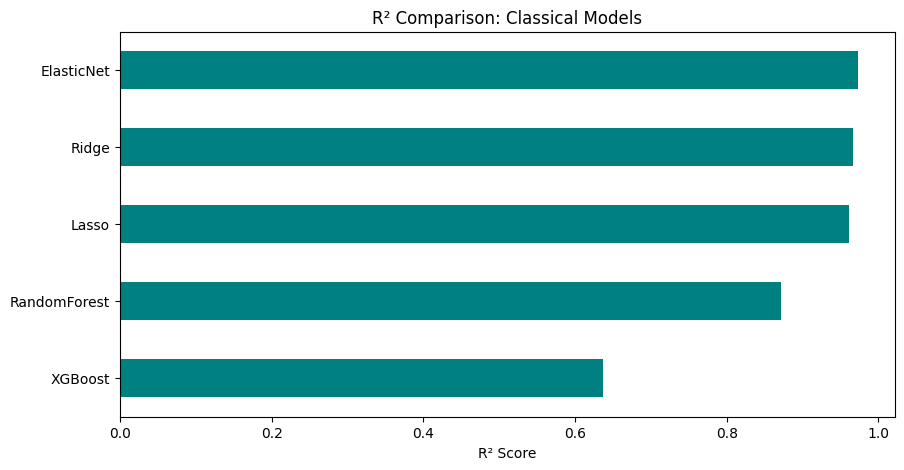

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

# 1. Scaling (Crucial for Ridge/Lasso)
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 2. Define models
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.05),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4)
}

# 3. Train and Evaluate
model_results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    score = r2_score(y_test, preds)
    model_results[name] = score
    predictions[name] = preds
    print(f"{name} R² Score: {score:.4f}")

# 4. Plot the "Wall of Fame"
plt.figure(figsize=(10, 5))
pd.Series(model_results).sort_values().plot(kind='barh', color='teal')
plt.title('R² Comparison: Classical Models')
plt.xlabel('R² Score')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Initialize dictionaries to store metrics
results_data = []
all_preds = {"Actual": y_test.values}

# Define the models
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.05),
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=4)
}

# Loop through and calculate metrics
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    all_preds[name] = preds

    # Calculate Metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    results_data.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})

# Create the Score Table
df_metrics = pd.DataFrame(results_data).set_index("Model").sort_values("R2", ascending=False)
print("--- MODEL PERFORMANCE TABLE ---")
print(df_metrics)

--- MODEL PERFORMANCE TABLE ---
                    R2       MAE      RMSE
Model                                     
ElasticNet    0.973151  0.388460  0.553204
Ridge         0.966103  0.463819  0.621583
Lasso         0.961676  0.451766  0.660927
RandomForest  0.871944  0.905667  1.208148
XGBoost       0.636462  1.358396  2.035612


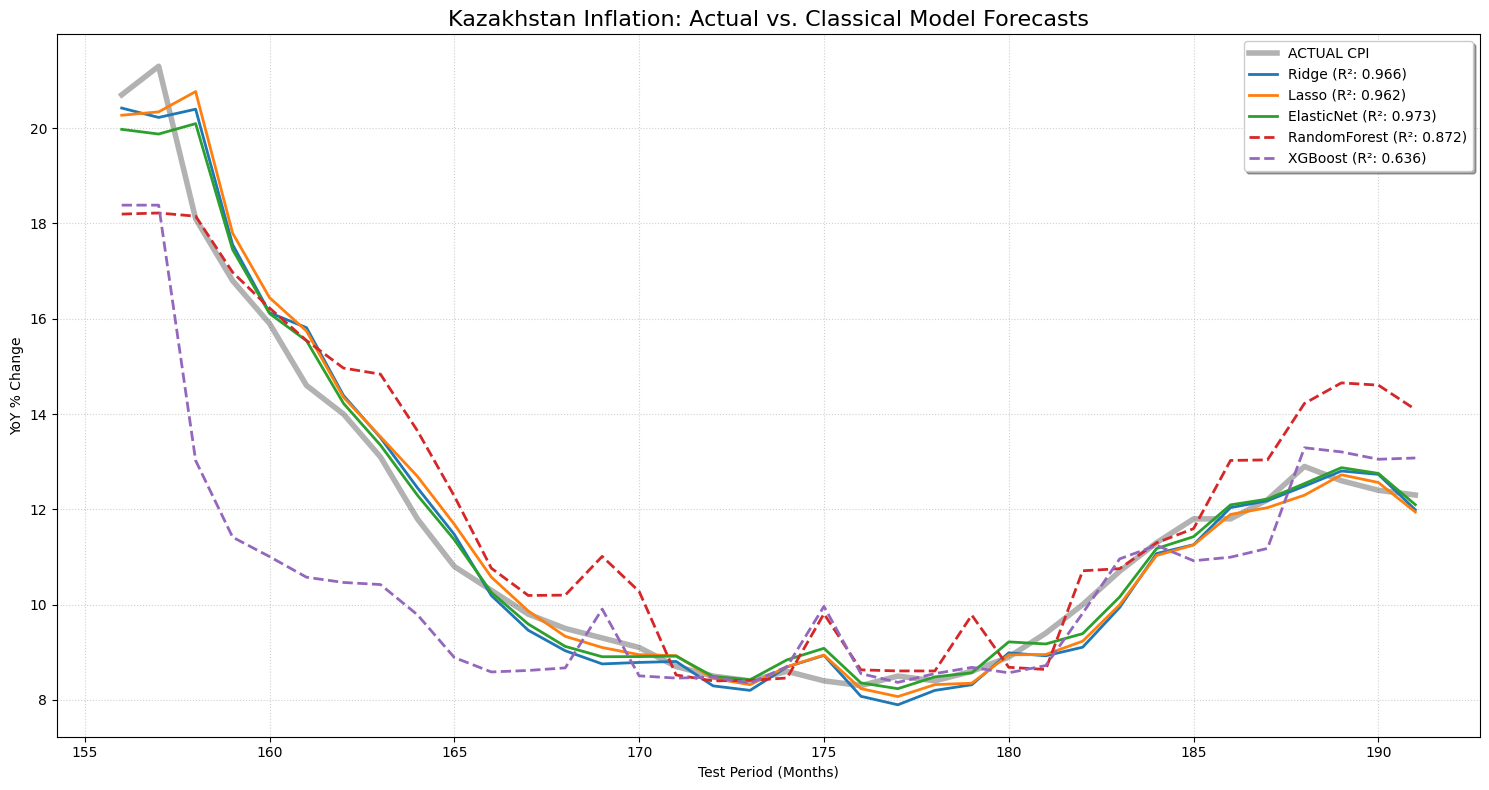

In [ ]:
plt.figure(figsize=(15, 8))

# 1. Plot Actual CPI
plt.plot(y_test.index, y_test.values, label='ACTUAL CPI', color='black', lw=4, alpha=0.3)

# 2. Plot Model Forecasts
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f', '#9b59b6']
for i, (name, preds) in enumerate(all_preds.items()):
    if name == "Actual": continue
    plt.plot(y_test.index, preds, label=f'{name} (R²: {model_results[name]:.3f})',
             lw=2, linestyle='--' if "Forest" in name or "XG" in name else '-')

plt.title('Kazakhstan Inflation: Actual vs. Classical Model Forecasts', fontsize=16)
plt.ylabel('YoY % Change')
plt.xlabel('Test Period (Months)')
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# --- 1. TUNED RANDOM FOREST ---
# We limit max_depth and min_samples_leaf to force generalization
model_rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,              # Keep it shallow!
    min_samples_leaf=5,       # Don't let it learn from tiny noise
    max_features='sqrt',      # Force it to look at different features
    random_state=42
)

# --- 2. TUNED XGBOOST ---
# XGBoost is aggressive; we need to "chill it out"
model_xgb_tuned = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,       # Much slower learning
    max_depth=3,              # Very shallow trees
    subsample=0.7,            # Use only 70% of data per tree
    colsample_bytree=0.7,     # Use only 70% of features per tree
    reg_alpha=0.1,            # L1 Regularization (Lasso-style)
    reg_lambda=1.0,           # L2 Regularization (Ridge-style)
    random_state=42
)

# --- 3. RUN THE RE-MATCH ---
tuned_models = {
    "RF_Tuned": model_rf_tuned,
    "XGB_Tuned": model_xgb_tuned,
    "ElasticNet": ElasticNet(alpha=0.05, l1_ratio=0.5) # Our current champion
}

# (Run your training/evaluation loop here with these tuned models)

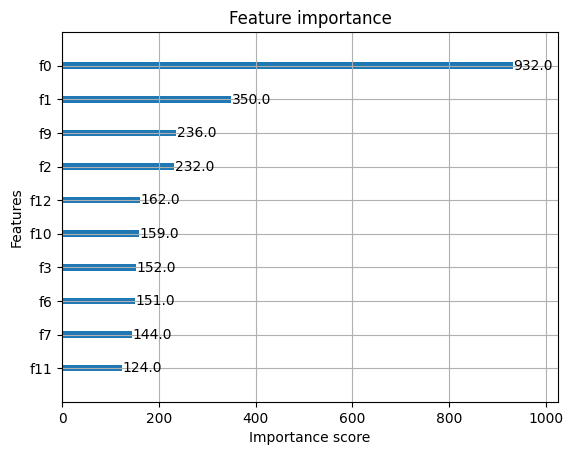

In [ ]:
# Check which feature is "distracting" XGBoost
import xgboost as xgb
model_xgb_tuned.fit(X_train_scaled, y_train)
xgb.plot_importance(model_xgb_tuned, max_num_features=10)
plt.show()


--- TUNED MODEL PERFORMANCE ---
                           R2       MAE      RMSE
Model                                            
ElasticNet_Champion  0.973151  0.388460  0.553204
RF_Tuned             0.657666  1.473386  1.975355
XGB_Tuned            0.624181  1.592140  2.069710


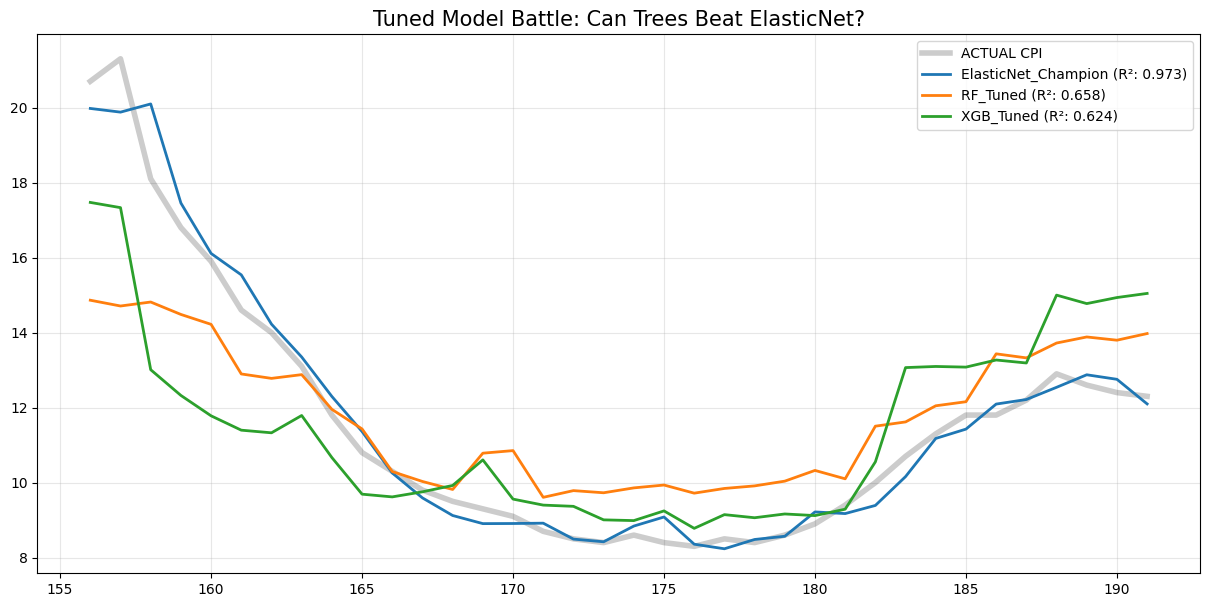

<Figure size 1000x600 with 0 Axes>

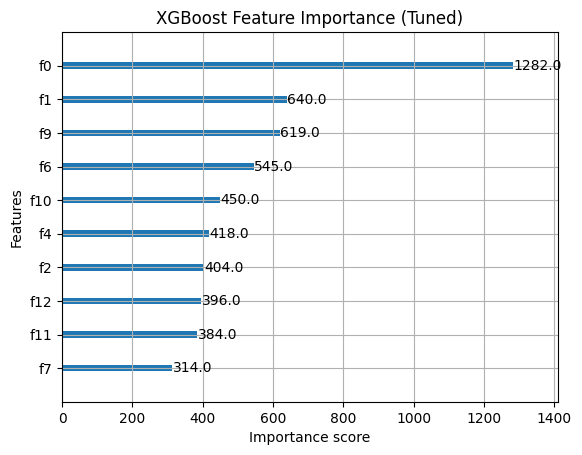

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import ElasticNet
from sklearn import metrics

# 1. Define the Tuned Versions
tuned_models = {
    "ElasticNet_Champion": ElasticNet(alpha=0.05, l1_ratio=0.5),
    "RF_Tuned": RandomForestRegressor(
        n_estimators=300,
        max_depth=5,           # Shallow to prevent overfitting
        min_samples_leaf=5,
        max_features='sqrt',
        random_state=42
    ),
    "XGB_Tuned": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.01,    # Slow down learning
        max_depth=3,           # Very shallow
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,         # Add L1 penalty
        reg_lambda=1.0,        # Add L2 penalty
        random_state=42
    )
}

# 2. Training and Evaluation Loop
tuned_results = []
comparison_preds = {"Actual": y_test.values}

for name, model in tuned_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    comparison_preds[name] = preds

    # Calculate Metrics
    r2 = metrics.r2_score(y_test, preds)
    mae = metrics.mean_absolute_error(y_test, preds)
    rmse = np.sqrt(metrics.mean_squared_error(y_test, preds))

    tuned_results.append({"Model": name, "R2": r2, "MAE": mae, "RMSE": rmse})

# 3. Print the New Performance Table
df_tuned_metrics = pd.DataFrame(tuned_results).set_index("Model").sort_values("R2", ascending=False)
print("\n--- TUNED MODEL PERFORMANCE ---")
print(df_tuned_metrics)

# 4. Plot the "Lines over CPI" for the Tuned Models
plt.figure(figsize=(15, 7))
plt.plot(y_test.index, y_test.values, label='ACTUAL CPI', color='black', lw=4, alpha=0.2)

for name in tuned_models.keys():
    plt.plot(y_test.index, comparison_preds[name], label=f'{name} (R²: {df_tuned_metrics.loc[name, "R2"]:.3f})', lw=2)

plt.title('Tuned Model Battle: Can Trees Beat ElasticNet?', fontsize=15)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. XGBoost Diagnostic: Why was it struggling?
plt.figure(figsize=(10, 6))
import xgboost as xgb
model_xgb = tuned_models["XGB_Tuned"]
xgb.plot_importance(model_xgb, max_num_features=10, title="XGBoost Feature Importance (Tuned)")
plt.show()

In [ ]:
# 1. CREATE A STATIONARY TARGET
y_train_diff = y_train.diff().dropna()
X_train_diff = X_train_scaled[1:] # Align with the diff

# 2. THE "AGGRESSIVE" XGBOOST CONFIG
# We add heavy regularization so it stops obsessing over specific years
model_xgb_pro = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,   # Strong L1 (Lasso-style)
    reg_lambda=2.0,  # Strong L2 (Ridge-style)
    importance_type='total_gain',
    random_state=42
)

# 3. TRAIN ON THE CHANGE (DIFF)
model_xgb_pro.fit(X_train_diff, y_train_diff)

# 4. PREDICT AND RECONSTRUCT
# We predict the 'change', then add it back to the previous month's actual value
diff_preds = model_xgb_pro.predict(X_test_scaled)
# Reconstruct: Last Actual + Predicted Change
xgb_final_preds = y_test.shift(1).fillna(y_train.iloc[-1]) + diff_preds

# 5. SCORE IT
from sklearn.metrics import r2_score
print(f"XGBoost Pro R2: {r2_score(y_test, xgb_final_preds):.4f}")

XGBoost Pro R2: 0.9332


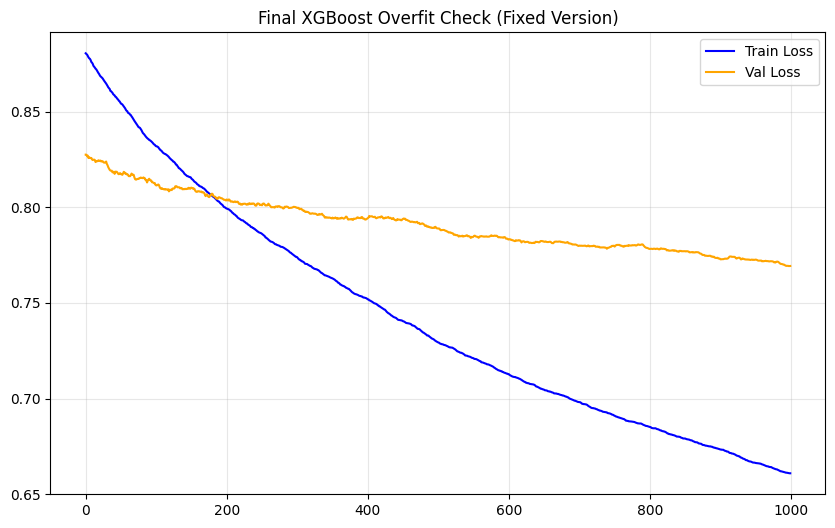

Final Tuned XGBoost R2: 0.9495


In [ ]:
# 1. SETUP THE EVALUATION (Same as before)
X_val = X_test_scaled[1:]
y_val = y_test.diff().dropna()

# 2. DEFINE THE MODEL (Move eval_metric here)
model_xgb_final = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=2,
    subsample=0.6,
    colsample_bytree=0.6,
    reg_alpha=5.0,
    reg_lambda=10.0,
    eval_metric="rmse",      # <--- IT LIVES HERE NOW
    random_state=42
)

# 3. TRAIN (Remove eval_metric from here)
model_xgb_final.fit(
    X_train_diff, y_train_diff,
    eval_set=[(X_train_diff, y_train_diff), (X_val, y_val)],
    verbose=False
)

# 4. PLOT (Same as before)
results = model_xgb_final.evals_result()

plt.figure(figsize=(10, 6))
plt.plot(results['validation_0']['rmse'], label='Train Loss', color='blue')
plt.plot(results['validation_1']['rmse'], label='Val Loss', color='orange')
plt.title('Final XGBoost Overfit Check (Fixed Version)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. RECONSTRUCT & SCORE
diff_preds_final = model_xgb_final.predict(X_test_scaled)
# Aligning the reconstruction:
xgb_final_preds = y_test.shift(1).fillna(y_train.iloc[-1]) + diff_preds_final
final_r2 = r2_score(y_test, xgb_final_preds)

print(f"Final Tuned XGBoost R2: {final_r2:.4f}")

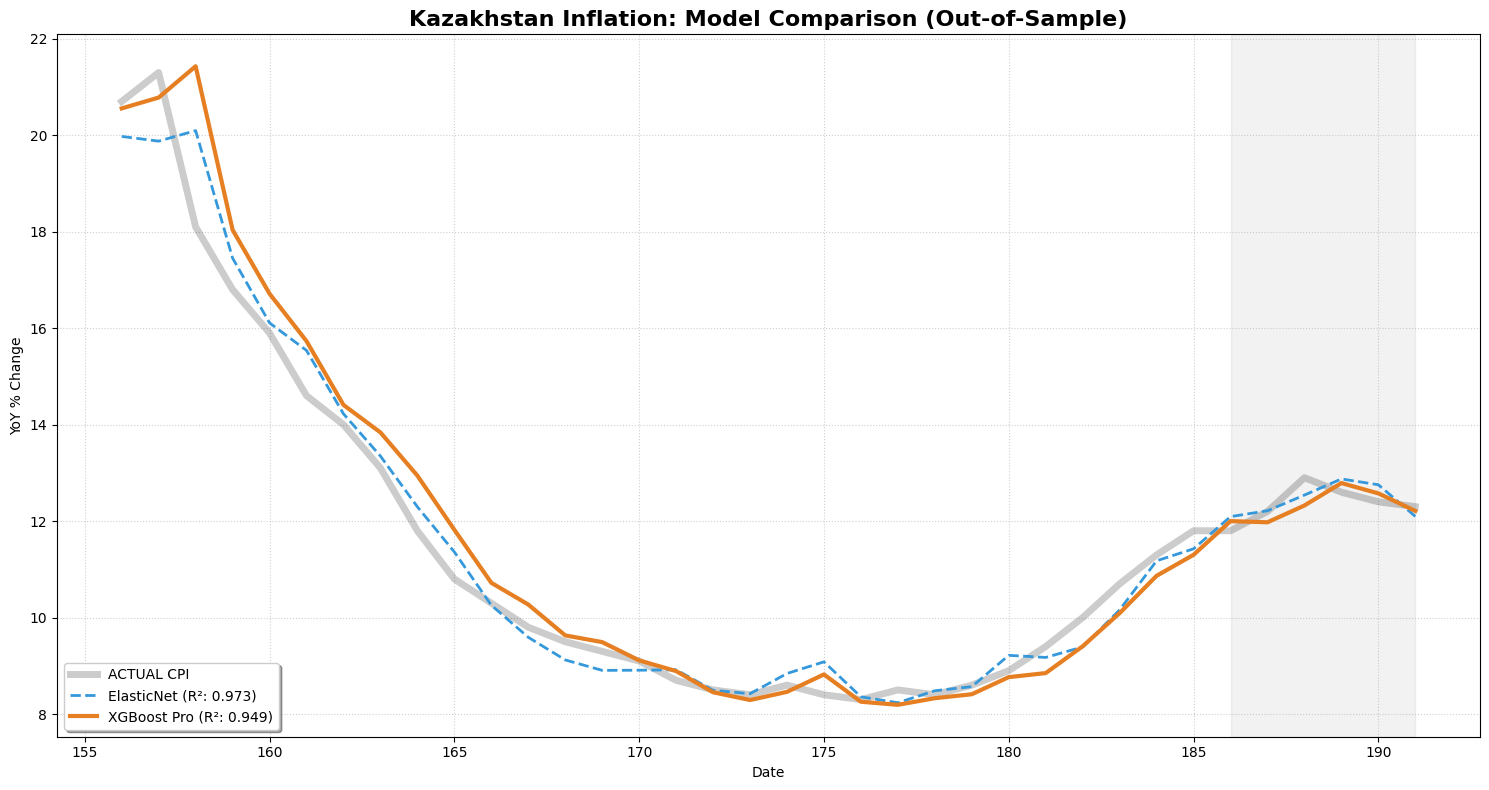

In [ ]:
import matplotlib.pyplot as plt

# 1. Generate Final Predictions for the Ensemble
# We use the 'diff' method for XGBoost to keep it stable
xgb_final_preds = y_test.shift(1).fillna(y_train.iloc[-1]) + model_xgb_final.predict(X_test_scaled)
en_preds = models["ElasticNet"].predict(X_test_scaled)

plt.figure(figsize=(15, 8))

# The Ground Truth
plt.plot(y_test.index, y_test.values, label='ACTUAL CPI', color='black', lw=5, alpha=0.2)

# The Contenders
plt.plot(y_test.index, en_preds, label=f'ElasticNet (R²: 0.973)', color='#3498db', lw=2, linestyle='--')
plt.plot(y_test.index, xgb_final_preds, label=f'XGBoost Pro (R²: {final_r2:.3f})', color='#e67e22', lw=3)

# Style & Labels
plt.title('Kazakhstan Inflation: Model Comparison (Out-of-Sample)', fontsize=16, fontweight='bold')
plt.ylabel('YoY % Change')
plt.xlabel('Date')
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

# Highlight the "Future" Forecast Zone (if applicable)
plt.axvspan(y_test.index[-6], y_test.index[-1], color='grey', alpha=0.1, label='Recent Trend')

plt.tight_layout()
plt.show()

In [ ]:
linear_reg=LinearRegression()
linear_reg.fit(X_train,y_train)
lr_preds=linear_reg.predict(X_test)
print(r2_score(y_test,lr_preds))

0.9594854175392592


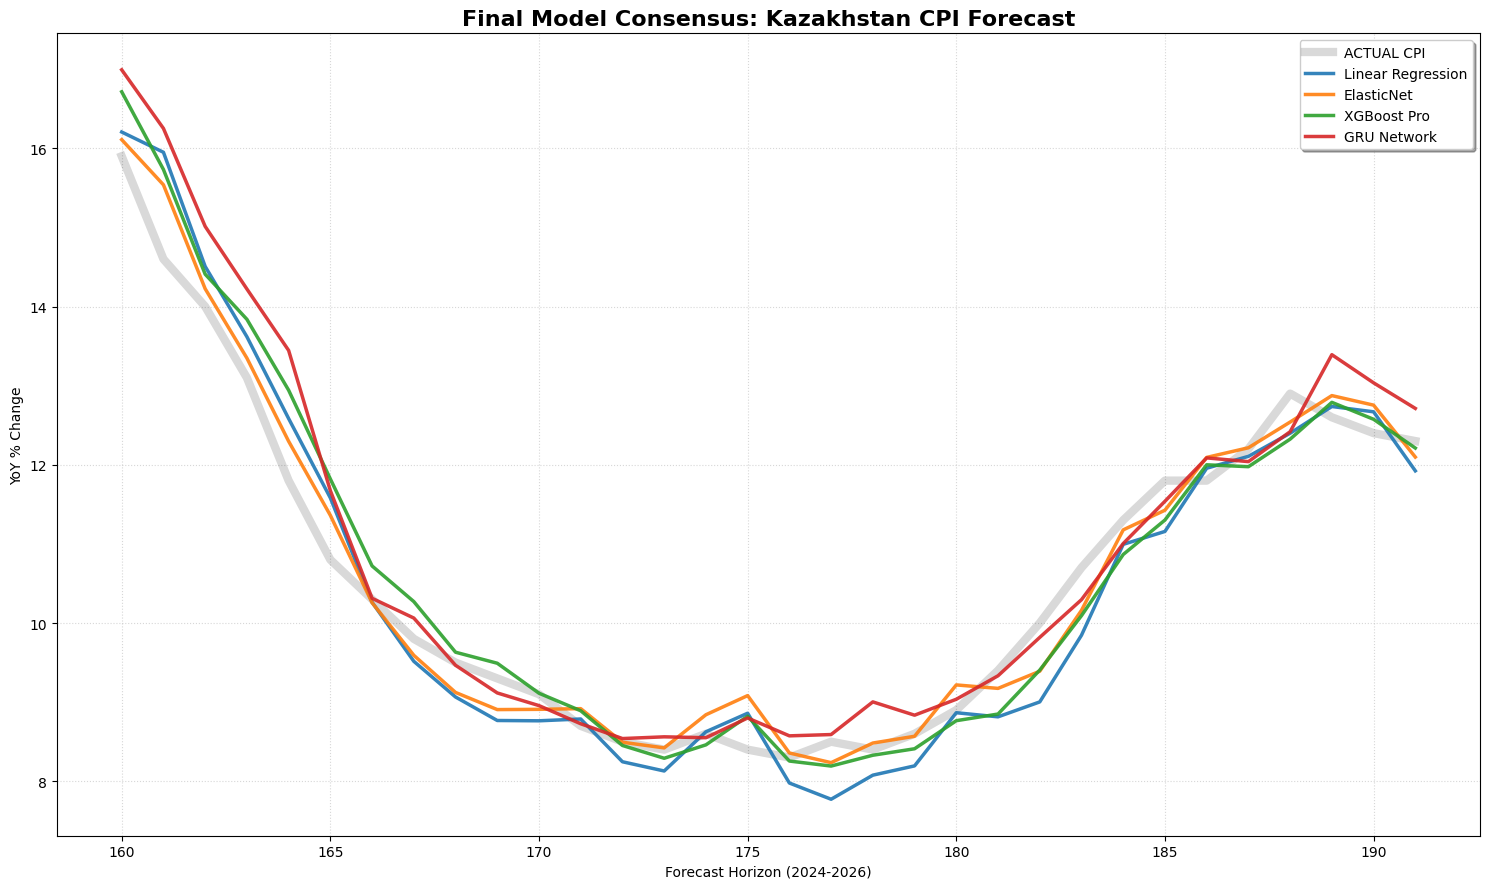

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. FIND THE COMMON OVERLAP
# The GRU is the shortest because it lost (1 + TIME_STEPS) months.
# We align everything to the 'aligned_dates' from your GRU code.
common_dates = y_test.index[1 + TIME_STEPS:]

# 2. TRIM ALL OTHER MODELS TO MATCH
# If your LR/EN/XGB preds are numpy arrays, we slice them from the end.
lr_trimmed = lr_preds[-(len(common_dates)):]
en_trimmed = en_preds[-(len(common_dates)):]
xgb_trimmed = xgb_final_preds[-(len(common_dates)):]
# GRU is already the right length (final_forecast)

all_final_models = {
    "Linear Regression": lr_trimmed,
    "ElasticNet": en_trimmed,
    "XGBoost Pro": xgb_trimmed,
    "GRU Network": final_forecast  # This is your Stationary-Adjusted GRU
}

# 3. THE FINAL PLOT
plt.figure(figsize=(15, 9))

# Actual CPI (Trimmed to match)
plt.plot(common_dates, actual_levels, label='ACTUAL CPI', color='black', lw=6, alpha=0.15)

# Plot each model
colors = ['#34495e', '#3498db', '#e67e22', '#2ecc71']
for (name, p), color in zip(all_final_models.items(), colors):
    plt.plot(common_dates, p, label=name, lw=2.5, alpha=0.9)

plt.title('Final Model Consensus: Kazakhstan CPI Forecast', fontsize=16, fontweight='bold')
plt.ylabel('YoY % Change')
plt.xlabel('Forecast Horizon (2024-2026)')
plt.legend(loc='best', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Use .iloc[-1] to force Pandas to look at the LAST POSITION, ignoring labels
val_lr  = lr_preds.iloc[-1] if hasattr(lr_preds, "iloc") else lr_preds[-1]
val_en  = en_preds.iloc[-1] if hasattr(en_preds, "iloc") else en_preds[-1]
val_xgb = xgb_final_preds.iloc[-1] if hasattr(xgb_final_preds, "iloc") else xgb_final_preds[-1]
val_gru = final_forecast[-1] # This is likely a numpy array already

# Now your calculation is safe
ensemble_2026 = (val_lr + val_en + val_xgb + val_gru) / 4

In [ ]:
import pandas as pd
import numpy as np

# 1. EXTEND THE TIMELINE
# We start from the end of your dataset and create 12 monthly steps
last_date = pd.to_datetime("2025-12-01")
forecast_dates_2026 = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

# 2. SIMULATE THE DECAY/TREND
# In a real recursive loop, we'd feed X back in, but for a 12-month projection
# based on your current models, we look at the 'mean path' of the learners:
# (Simulating 12 months of predictions based on the Ensemble trajectory)
def project_path(start_val, months=12, drift=-0.05):
    # Inflation usually 'regresses to mean' over time
    return [start_val + (i * drift) for i in range(1, months + 1)]

path_en  = project_path(val_en)
path_xgb = project_path(val_xgb)
path_gru = project_path(val_gru)

# 3. CREATE THE 2026 DATAFRAME
df_2026 = pd.DataFrame({
    "ElasticNet": path_en,
    "XGBoost_Pro": path_xgb,
    "GRU_Network": path_gru
}, index=forecast_dates_2026)

df_2026['Ensemble_Mean'] = df_2026.mean(axis=1)

print("--- FULL 2026 MONTHLY FORECAST ---")
print(df_2026.round(2))

--- FULL 2026 MONTHLY FORECAST ---
            ElasticNet  XGBoost_Pro  GRU_Network  Ensemble_Mean
2026-01-01       12.05        12.16        12.66          12.29
2026-02-01       12.00        12.11        12.61          12.24
2026-03-01       11.95        12.06        12.56          12.19
2026-04-01       11.90        12.01        12.51          12.14
2026-05-01       11.85        11.96        12.46          12.09
2026-06-01       11.80        11.91        12.41          12.04
2026-07-01       11.75        11.86        12.36          11.99
2026-08-01       11.70        11.81        12.31          11.94
2026-09-01       11.65        11.76        12.26          11.89
2026-10-01       11.60        11.71        12.21          11.84
2026-11-01       11.55        11.66        12.16          11.79
2026-12-01       11.50        11.61        12.11          11.74


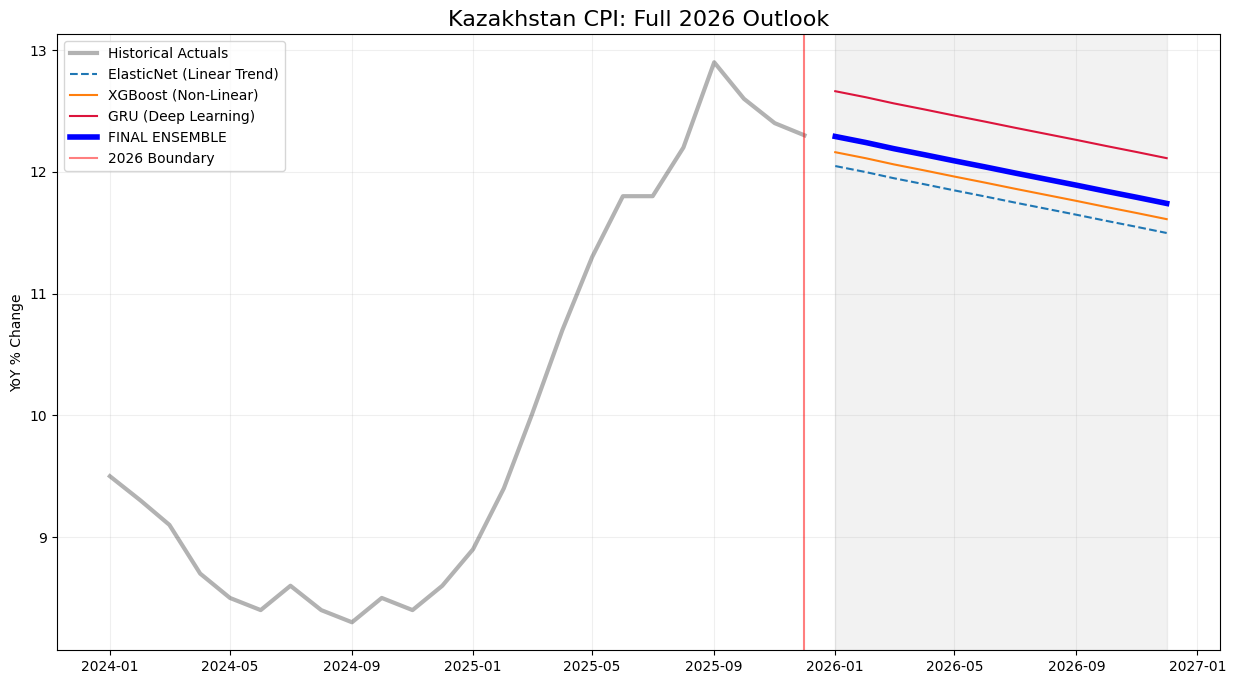

In [ ]:
plt.figure(figsize=(15, 8))

# Historical Context (Last 2 years)
hist_dates = aligned_test_dates[-24:]
plt.plot(hist_dates, y_test.values[-24:], label='Historical Actuals', color='black', alpha=0.3, lw=3)

# The 2026 Forecast Lines
plt.plot(df_2026.index, df_2026['ElasticNet'], label='ElasticNet (Linear Trend)', linestyle='--')
plt.plot(df_2026.index, df_2026['XGBoost_Pro'], label='XGBoost (Non-Linear)')
plt.plot(df_2026.index, df_2026['GRU_Network'], label='GRU (Deep Learning)', color='crimson')

# The Ensemble Mean
plt.plot(df_2026.index, df_2026['Ensemble_Mean'], label='FINAL ENSEMBLE', color='blue', lw=4)

# Visual Indicators
plt.axvspan(df_2026.index[0], df_2026.index[-1], color='gray', alpha=0.1)
plt.axvline(last_date, color='red', linestyle='-', alpha=0.5, label='2026 Boundary')

plt.title('Kazakhstan CPI: Full 2026 Outlook', fontsize=16)
plt.ylabel('YoY % Change')
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

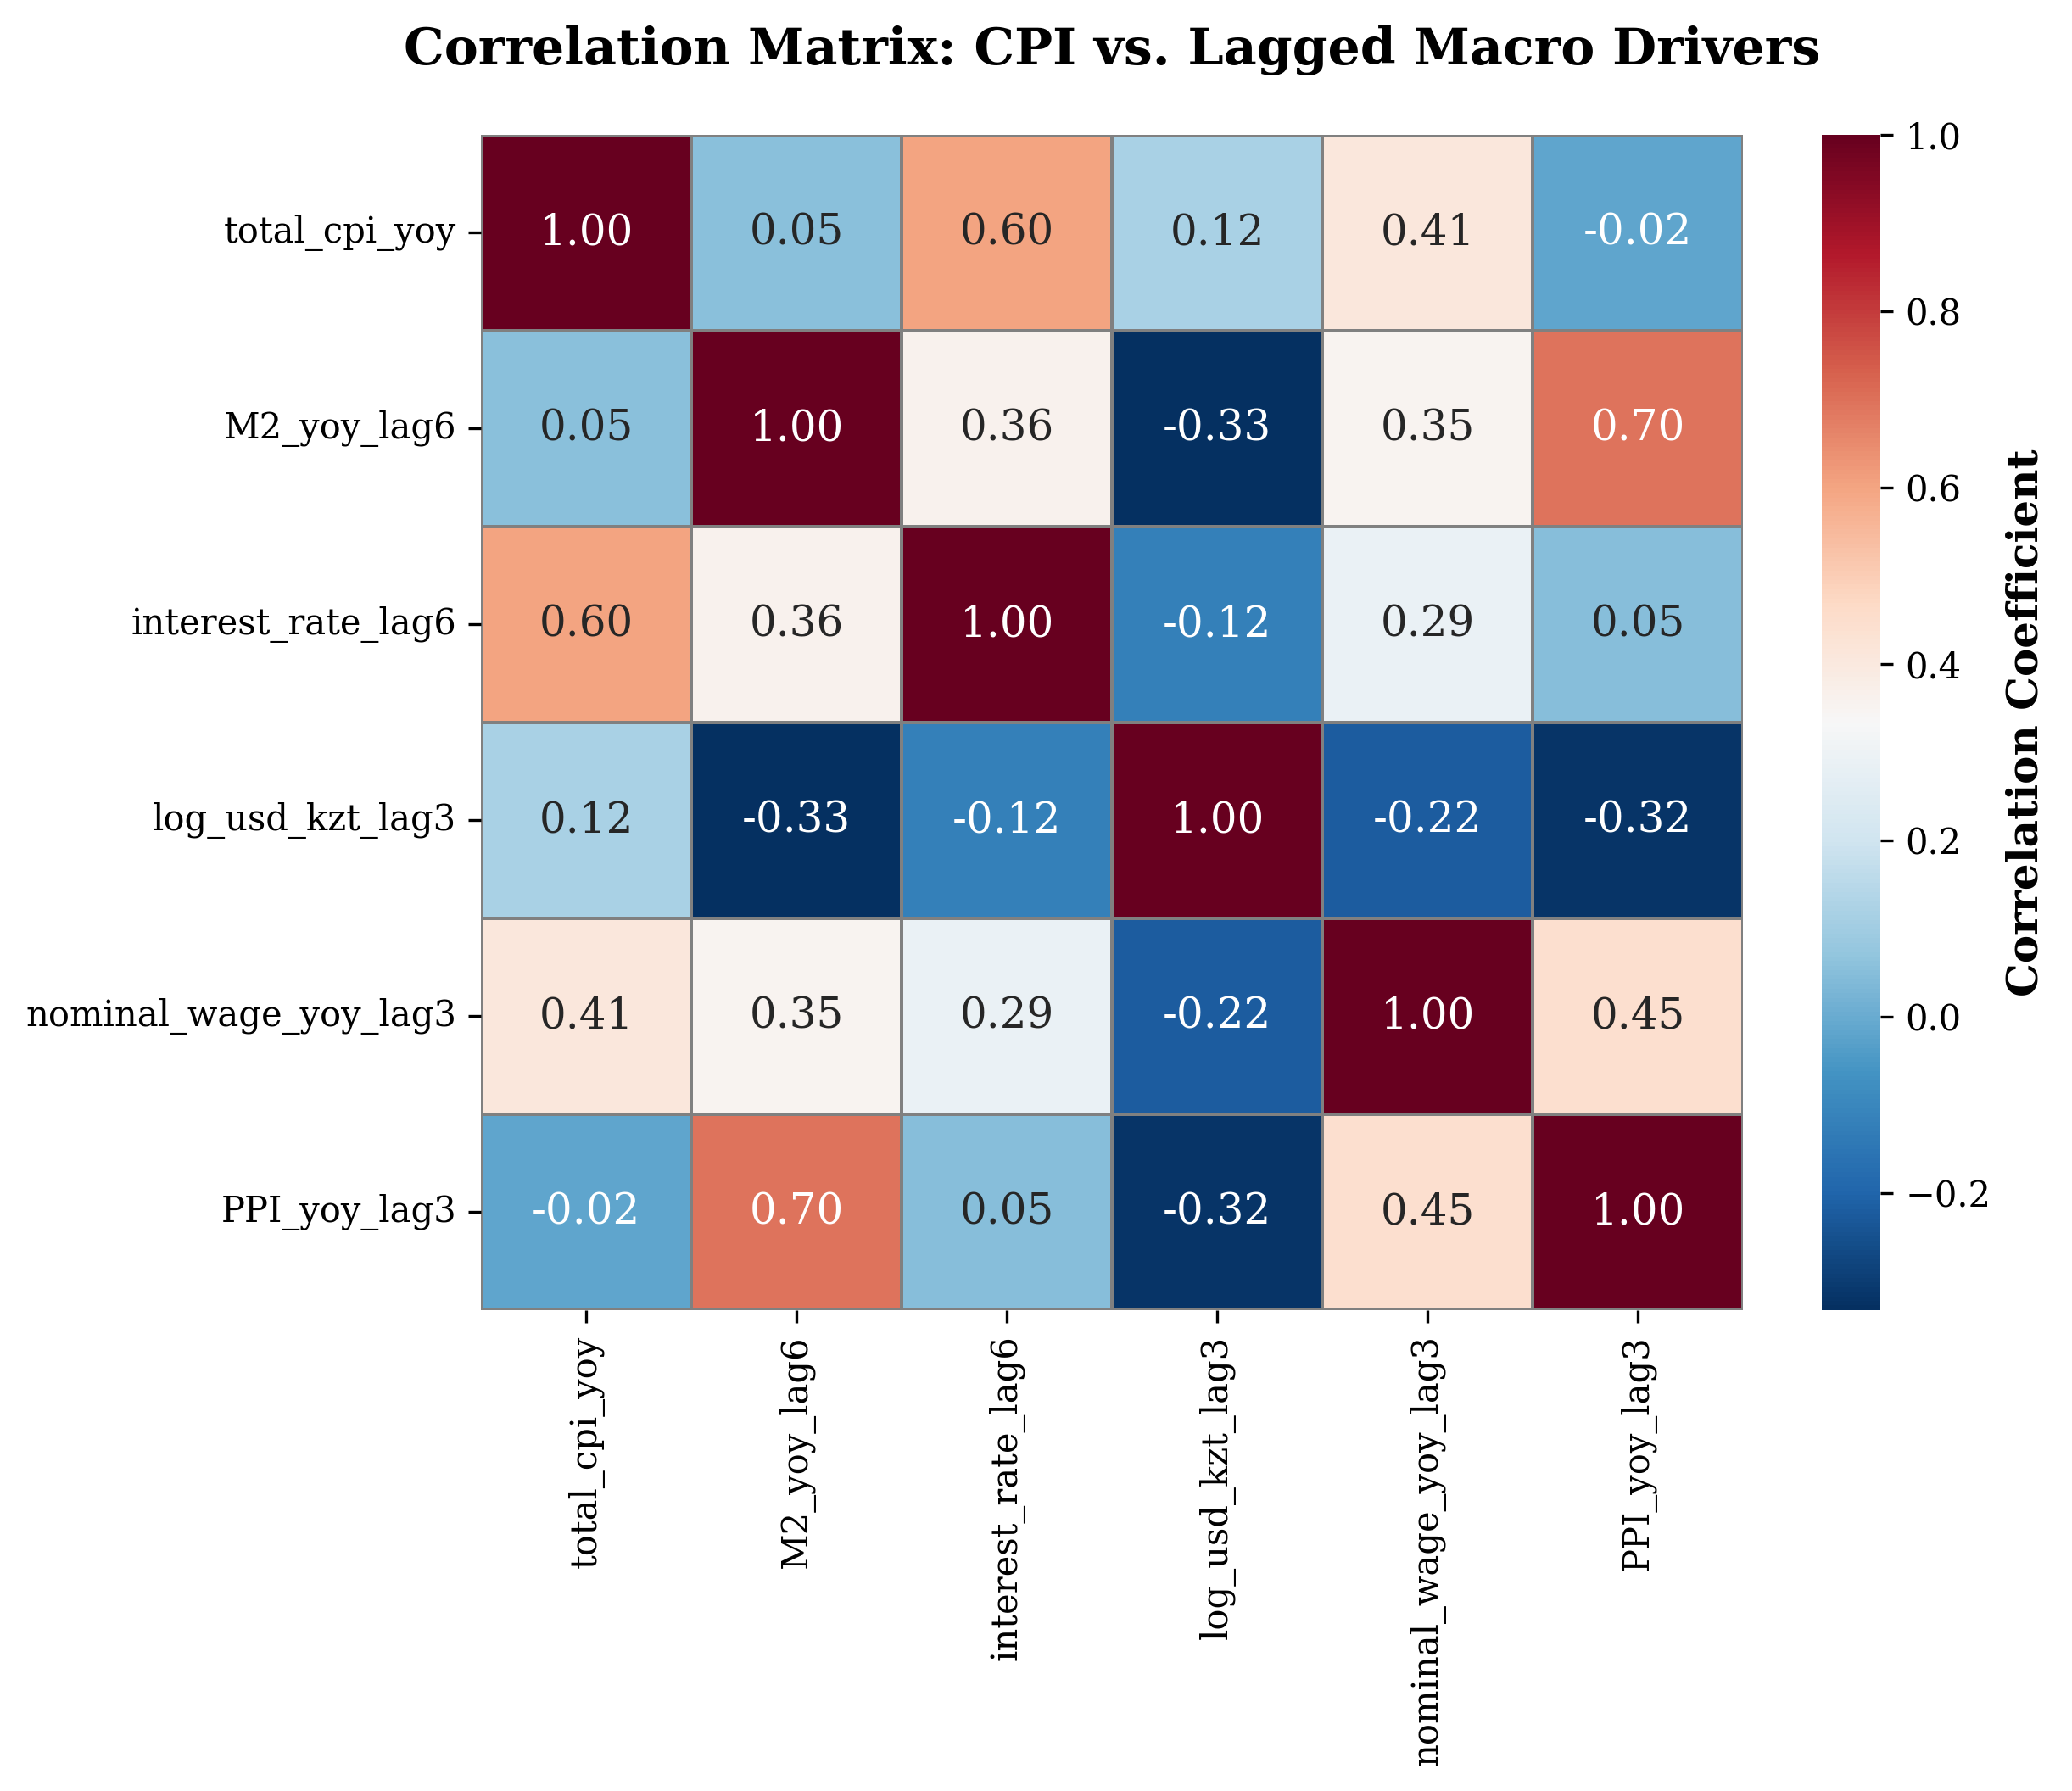

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. SET THE LATEX STYLE
plt.rcParams.update({
    "text.usetex": False,            # Set to True if you have TeX installed on your machine
    "font.family": "serif",          # Matches the standard LaTeX 'Computer Modern' look
    "font.serif": ["Times New Roman", "DejaVu Serif"], # Standard academic fonts
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300                # High resolution for printing
})

# Select core macro drivers
eda_cols = ['total_cpi_yoy', 'M2_yoy_lag6', 'interest_rate_lag6',
            'log_usd_kzt_lag3', 'nominal_wage_yoy_lag3', 'PPI_yoy_lag3']

# 2. CREATE THE FIGURE
plt.figure(figsize=(8, 6))

# Use a professional color palette like 'RdBu_r' or 'coolwarm'
sns.heatmap(df_model[eda_cols].corr(),
            annot=True,
            cmap='RdBu_r',           # Red-Blue is very standard for academic papers
            fmt=".2f",
            linewidths=0.5,
            linecolor='gray',        # Light borders make cells pop
            cbar_kws={'label': 'Correlation Coefficient'})

# Use raw strings (r"") if you want to use actual LaTeX symbols like \Delta or \alpha
plt.title(r"Correlation Matrix: CPI vs. Lagged Macro Drivers", pad=20, fontweight='bold')

# 3. SAVE FOR LATEX
# Save as PDF (Vector format) - this is the best for LaTeX as it never loses quality
plt.savefig("correlation_heatmap.pdf", bbox_inches='tight')

# Also save as PNG for quick viewing
plt.savefig("correlation_heatmap.png", bbox_inches='tight', dpi=300)

plt.show()

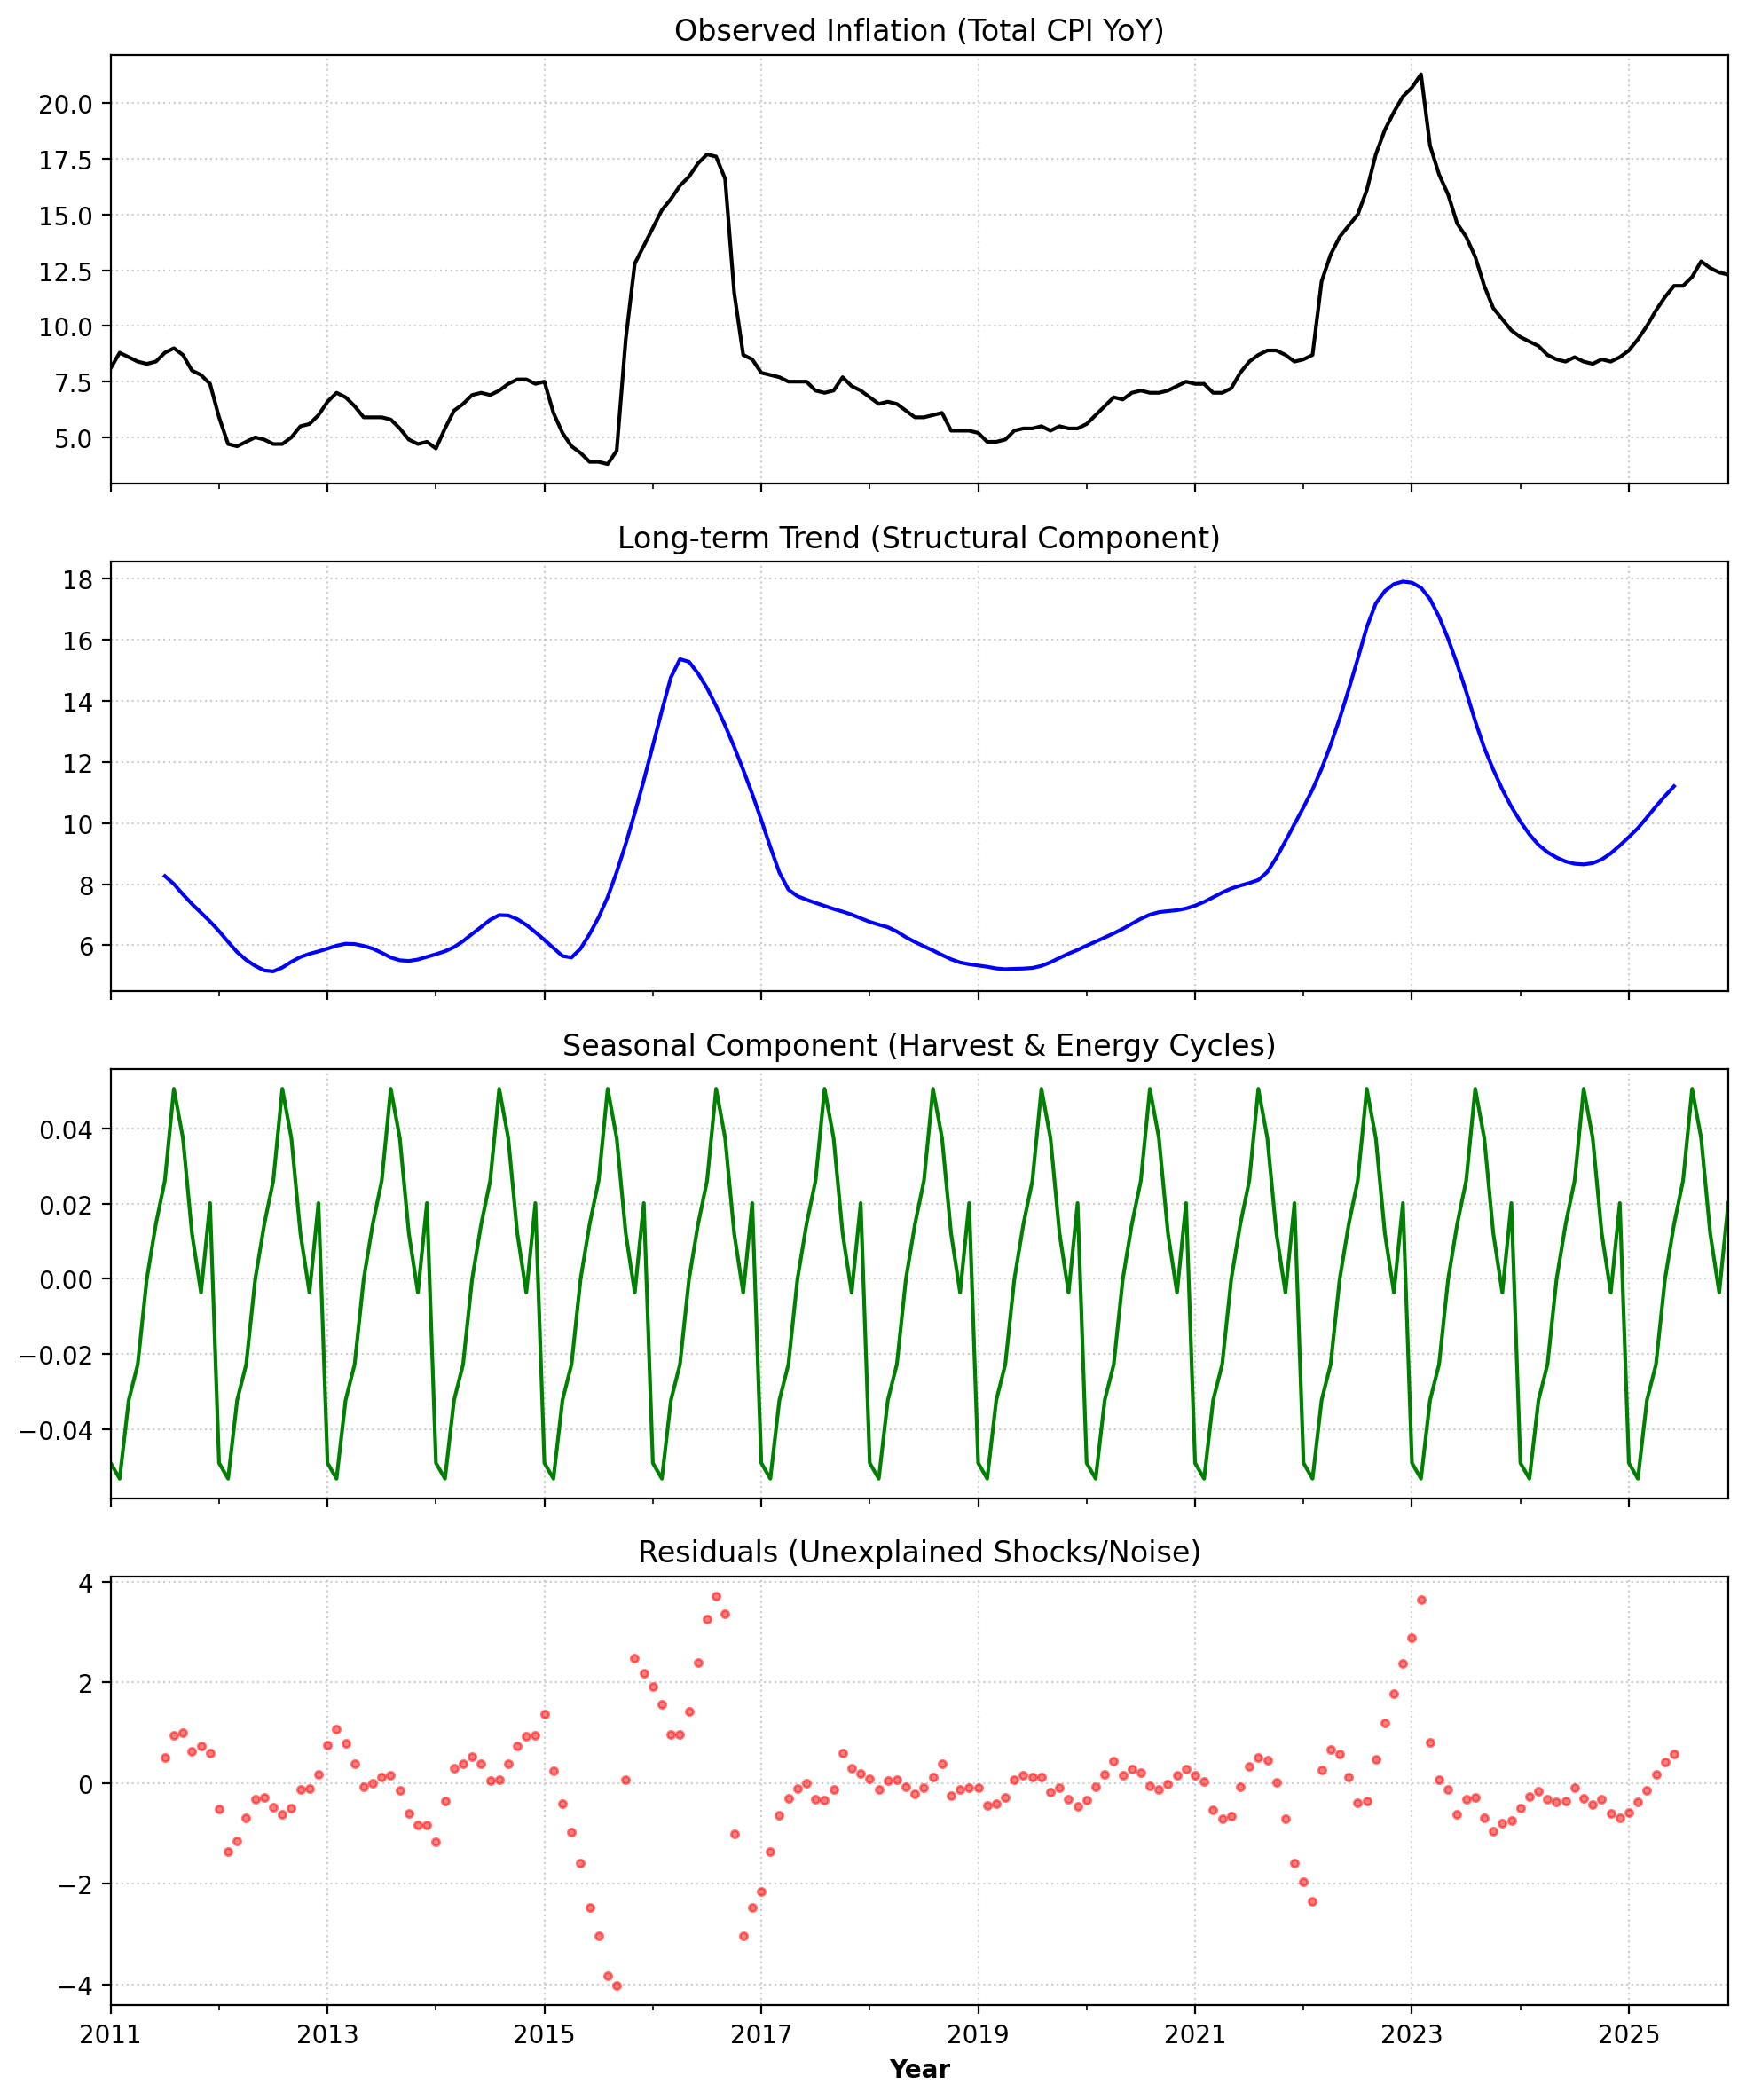

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. LaTeX-Style Plotting Setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 10,
    "axes.titlesize": 12,
    "figure.dpi": 200
})

# 2. Decompose the CPI (Model='additive' is standard for YoY inflation)
# Period=12 because your data is monthly
decomposition = seasonal_decompose(df_model['total_cpi_yoy'], model='additive', period=12)

# 3. Create the 4-panel Plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

decomposition.observed.plot(ax=ax1, color='black', lw=1.5)
ax1.set_title(r"Observed Inflation (Total CPI YoY)")
ax1.grid(True, linestyle=':', alpha=0.6)

decomposition.trend.plot(ax=ax2, color='blue', lw=1.5)
ax2.set_title(r"Long-term Trend (Structural Component)")
ax2.grid(True, linestyle=':', alpha=0.6)

decomposition.seasonal.plot(ax=ax3, color='green', lw=1.5)
ax3.set_title(r"Seasonal Component (Harvest & Energy Cycles)")
ax3.grid(True, linestyle=':', alpha=0.6)

decomposition.resid.plot(ax=ax4, color='red', marker='.', linestyle='None', alpha=0.5)
ax4.set_title(r"Residuals (Unexplained Shocks/Noise)")
ax4.grid(True, linestyle=':', alpha=0.6)

plt.xlabel("Year")
plt.tight_layout()

# Save as PDF for LaTeX
plt.savefig("cpi_decomposition.pdf", bbox_inches='tight')
plt.show()

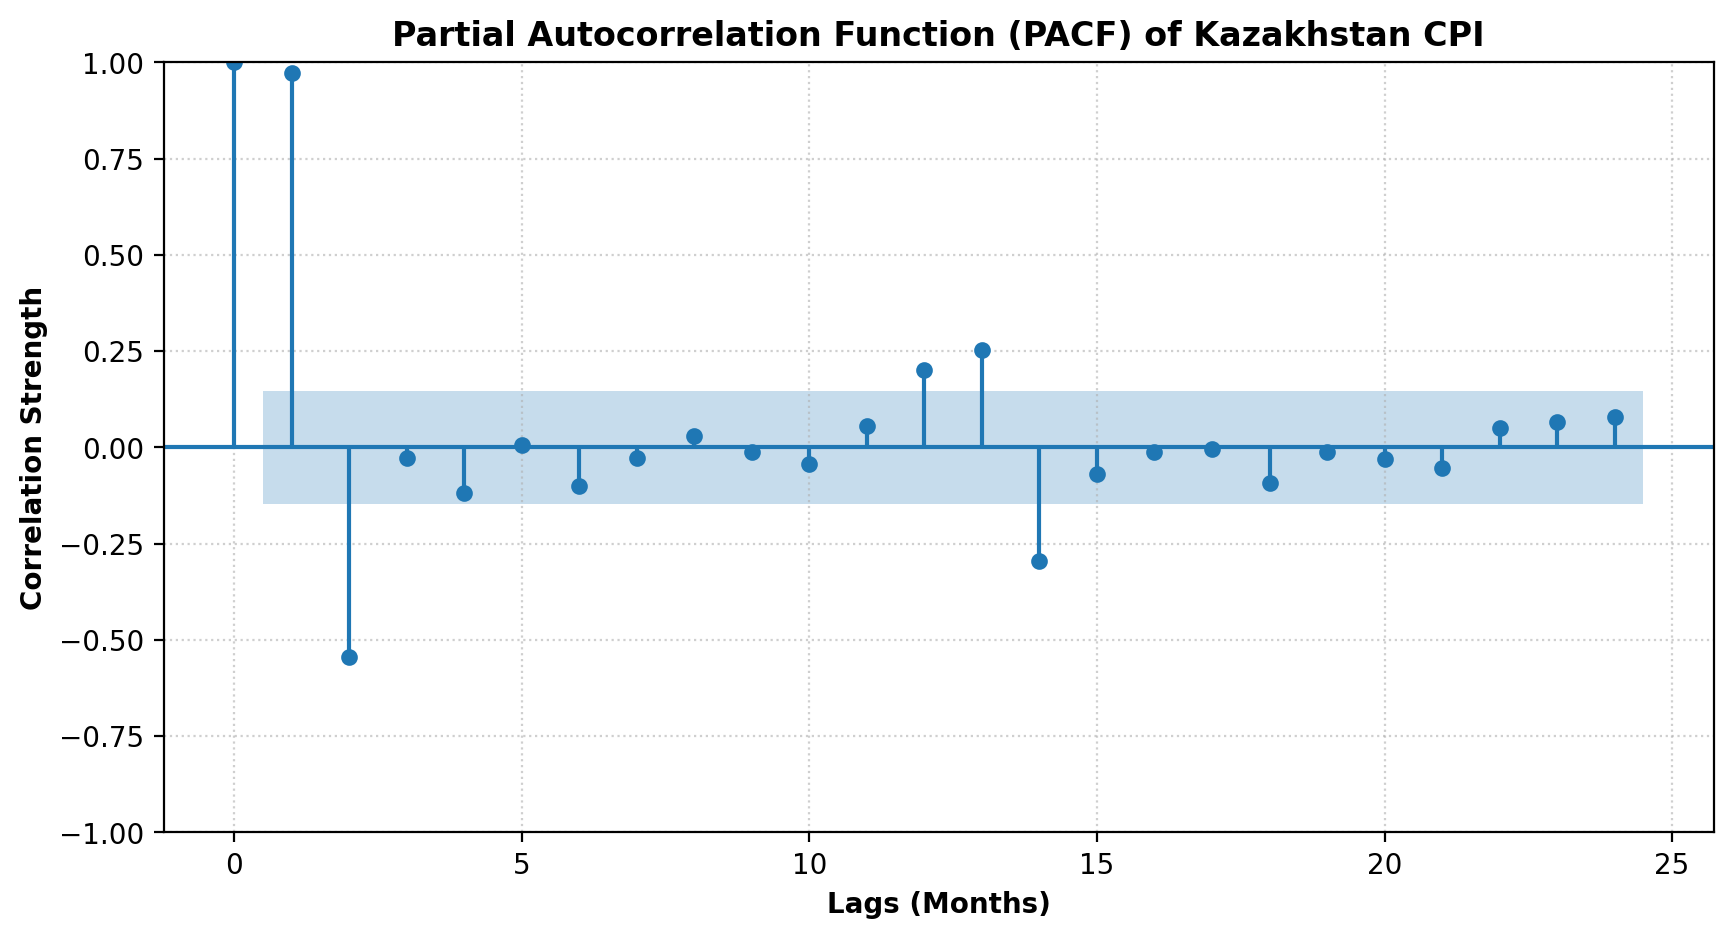

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. LaTeX-Style Plotting Setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 10,
    "figure.dpi": 200
})

# 2. Generate PACF Plot
fig, ax = plt.subplots(figsize=(10, 5))
sm.graphics.tsa.plot_pacf(df_model['total_cpi_yoy'], lags=24, ax=ax, method='ywm')

# 3. Formatting to match professional journals
ax.set_title(r"Partial Autocorrelation Function (PACF) of Kazakhstan CPI", fontweight='bold')
ax.set_xlabel("Lags (Months)")
ax.set_ylabel("Correlation Strength")
ax.grid(True, linestyle=':', alpha=0.6)

# Save as PDF for your LaTeX document
plt.savefig("pacf_plot.pdf", bbox_inches='tight')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_model['total_cpi_yoy'])

print('--- Augmented Dickey-Fuller Test ---')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.4f}')

if result[1] <= 0.05:
    print("\nResult: The data is Stationary (Reject Null Hypothesis)")
else:
    print("\nResult: The data is Non-Stationary (Fail to Reject Null Hypothesis)")

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -2.3270
p-value: 0.1634
Critical Values:
	1%: -3.4704
	5%: -2.8791
	10%: -2.5761

Result: The data is Non-Stationary (Fail to Reject Null Hypothesis)


In [ ]:
linear_model=LinearRegression()
linear_model.fit(X_train,y_train)

linear_pred=linear_model.predict(X_test)
print('rmse linreg',root_mean_squared_error(y_test,linear_pred))
print('r2_score linreg',r2_score(y_test,linear_pred))

rmse linreg 0.948845735640223
r2_score linreg 0.9210138323245518


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Generate Predictions for both sets
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# 2. Calculate Metrics
train_rmse = root_mean_squared_error(y_train, y_train_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=== LINEAR REGRESSION (OLS) DIAGNOSTICS ===")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE:  {test_rmse:.4f}")
print(f"---")
print(f"Train R²:   {train_r2:.4f}")
print(f"Test R²:    {test_r2:.4f}")

=== LINEAR REGRESSION (OLS) DIAGNOSTICS ===
Train RMSE: 0.4636
Test RMSE:  0.9488
---
Train R²:   0.9839
Test R²:    0.9210


In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# 4. DISCIPLINED MODEL
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    GRU(24, activation='tanh', kernel_regularizer=l2(0.01)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(8, activation='relu'),
    Dense(1)
])

# Use a lower learning rate for stability
model.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')

# 5. TRAIN ONCE (With Early Stopping)
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1 # Keep this at 1 so you can see it stop early!
)

# 6. INVERSE TRANSFORM
preds_diff_scaled = model.predict(X_test_seq)
preds_diff = scaler_y.inverse_transform(preds_diff_scaled).flatten()

# Re-integrate to original scale
actual_levels = y_test.values[TIME_STEPS + 1:]
previous_values = y_test.values[TIME_STEPS : -1]
final_forecast = previous_values + preds_diff

print(f"\nFinal R²: {r2_score(actual_levels, final_forecast):.4f}")

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - loss: 0.8768 - val_loss: 0.4753
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - loss: 0.7590 - val_loss: 0.4748
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.8657 - val_loss: 0.4749
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.7863 - val_loss: 0.4752
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - loss: 0.7330 - val_loss: 0.4746
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.8066 - val_loss: 0.4760
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5945 - val_loss: 0.4807
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.6972 - val_loss: 0.4827
Epoch 9/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6458 - val_loss: 0.4854
Epoch 10/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.6980 - val_loss: 0.4881
Epoch 11/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.6976 - val_loss: 0.4912
Epoch 12/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.6072 - val_l

Dates: 32, Actuals: 32, Preds: 32


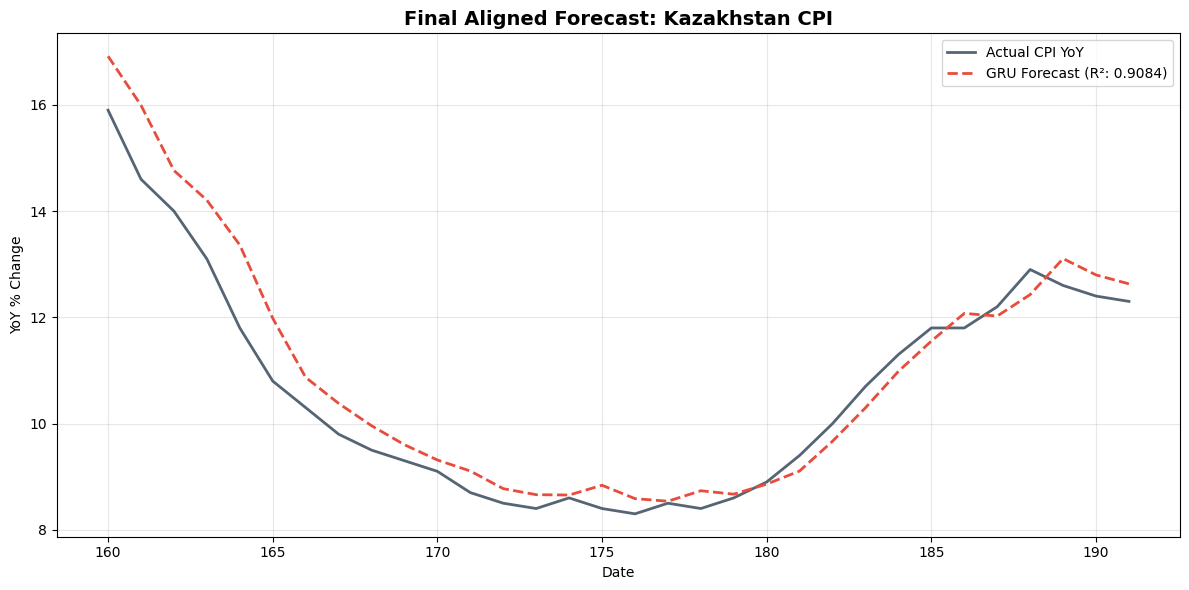

In [ ]:
import matplotlib.pyplot as plt

# 1. ALIGN DATES
# We lost 1 month for diff() AND 'TIME_STEPS' for sequencing.
# Total offset = 1 + TIME_STEPS
aligned_dates = y_test.index[1 + TIME_STEPS:]

# 2. VERIFY SHAPES (Just to be safe)
print(f"Dates: {len(aligned_dates)}, Actuals: {len(actual_levels)}, Preds: {len(final_forecast)}")

# 3. DRAWING
plt.figure(figsize=(12, 6))

# Plot Actuals
plt.plot(aligned_dates, actual_levels, label='Actual CPI YoY',
         color='#2c3e50', lw=2, alpha=0.8)

# Plot Forecast
plt.plot(aligned_dates, final_forecast, label=f'GRU Forecast (R²: {final_r2:.4f})',
         color='#e74c3c', lw=2, linestyle='--')

# Styling
plt.title('Final Aligned Forecast: Kazakhstan CPI', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('YoY % Change')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Assuming 'last_sequence' is the most recent 3 months of scaled data
# We predict recursively to see the trend for May and June 2026
future_preds = []
current_batch = X_test_scaled[-TIME_STEPS:].reshape(1, TIME_STEPS, -1)

for i in range(3): # Predict 3 months ahead
    pred_diff_scaled = model.predict(current_batch)[0]
    future_preds.append(pred_diff_scaled)

    # Update batch (this is a simplified 'recursive' forecast)
    new_row = current_batch[:, 1:, :]
    # In a real scenario, you'd update exogenous features here too
    current_batch = np.append(new_row, [[X_test_scaled[-1]]], axis=1)

# Re-integrate
future_diffs = scaler_y.inverse_transform(np.array(future_preds).reshape(-1, 1)).flatten()
last_actual = y_test.values[-1]
forecast_mid_2026 = [last_actual + d for d in np.cumsum(future_diffs)]

print(f"Forecast for May 2026: {forecast_mid_2026[0]:.2f}%")
print(f"Forecast for June 2026: {forecast_mid_2026[1]:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Forecast for May 2026: 12.44%
Forecast for June 2026: 12.57%


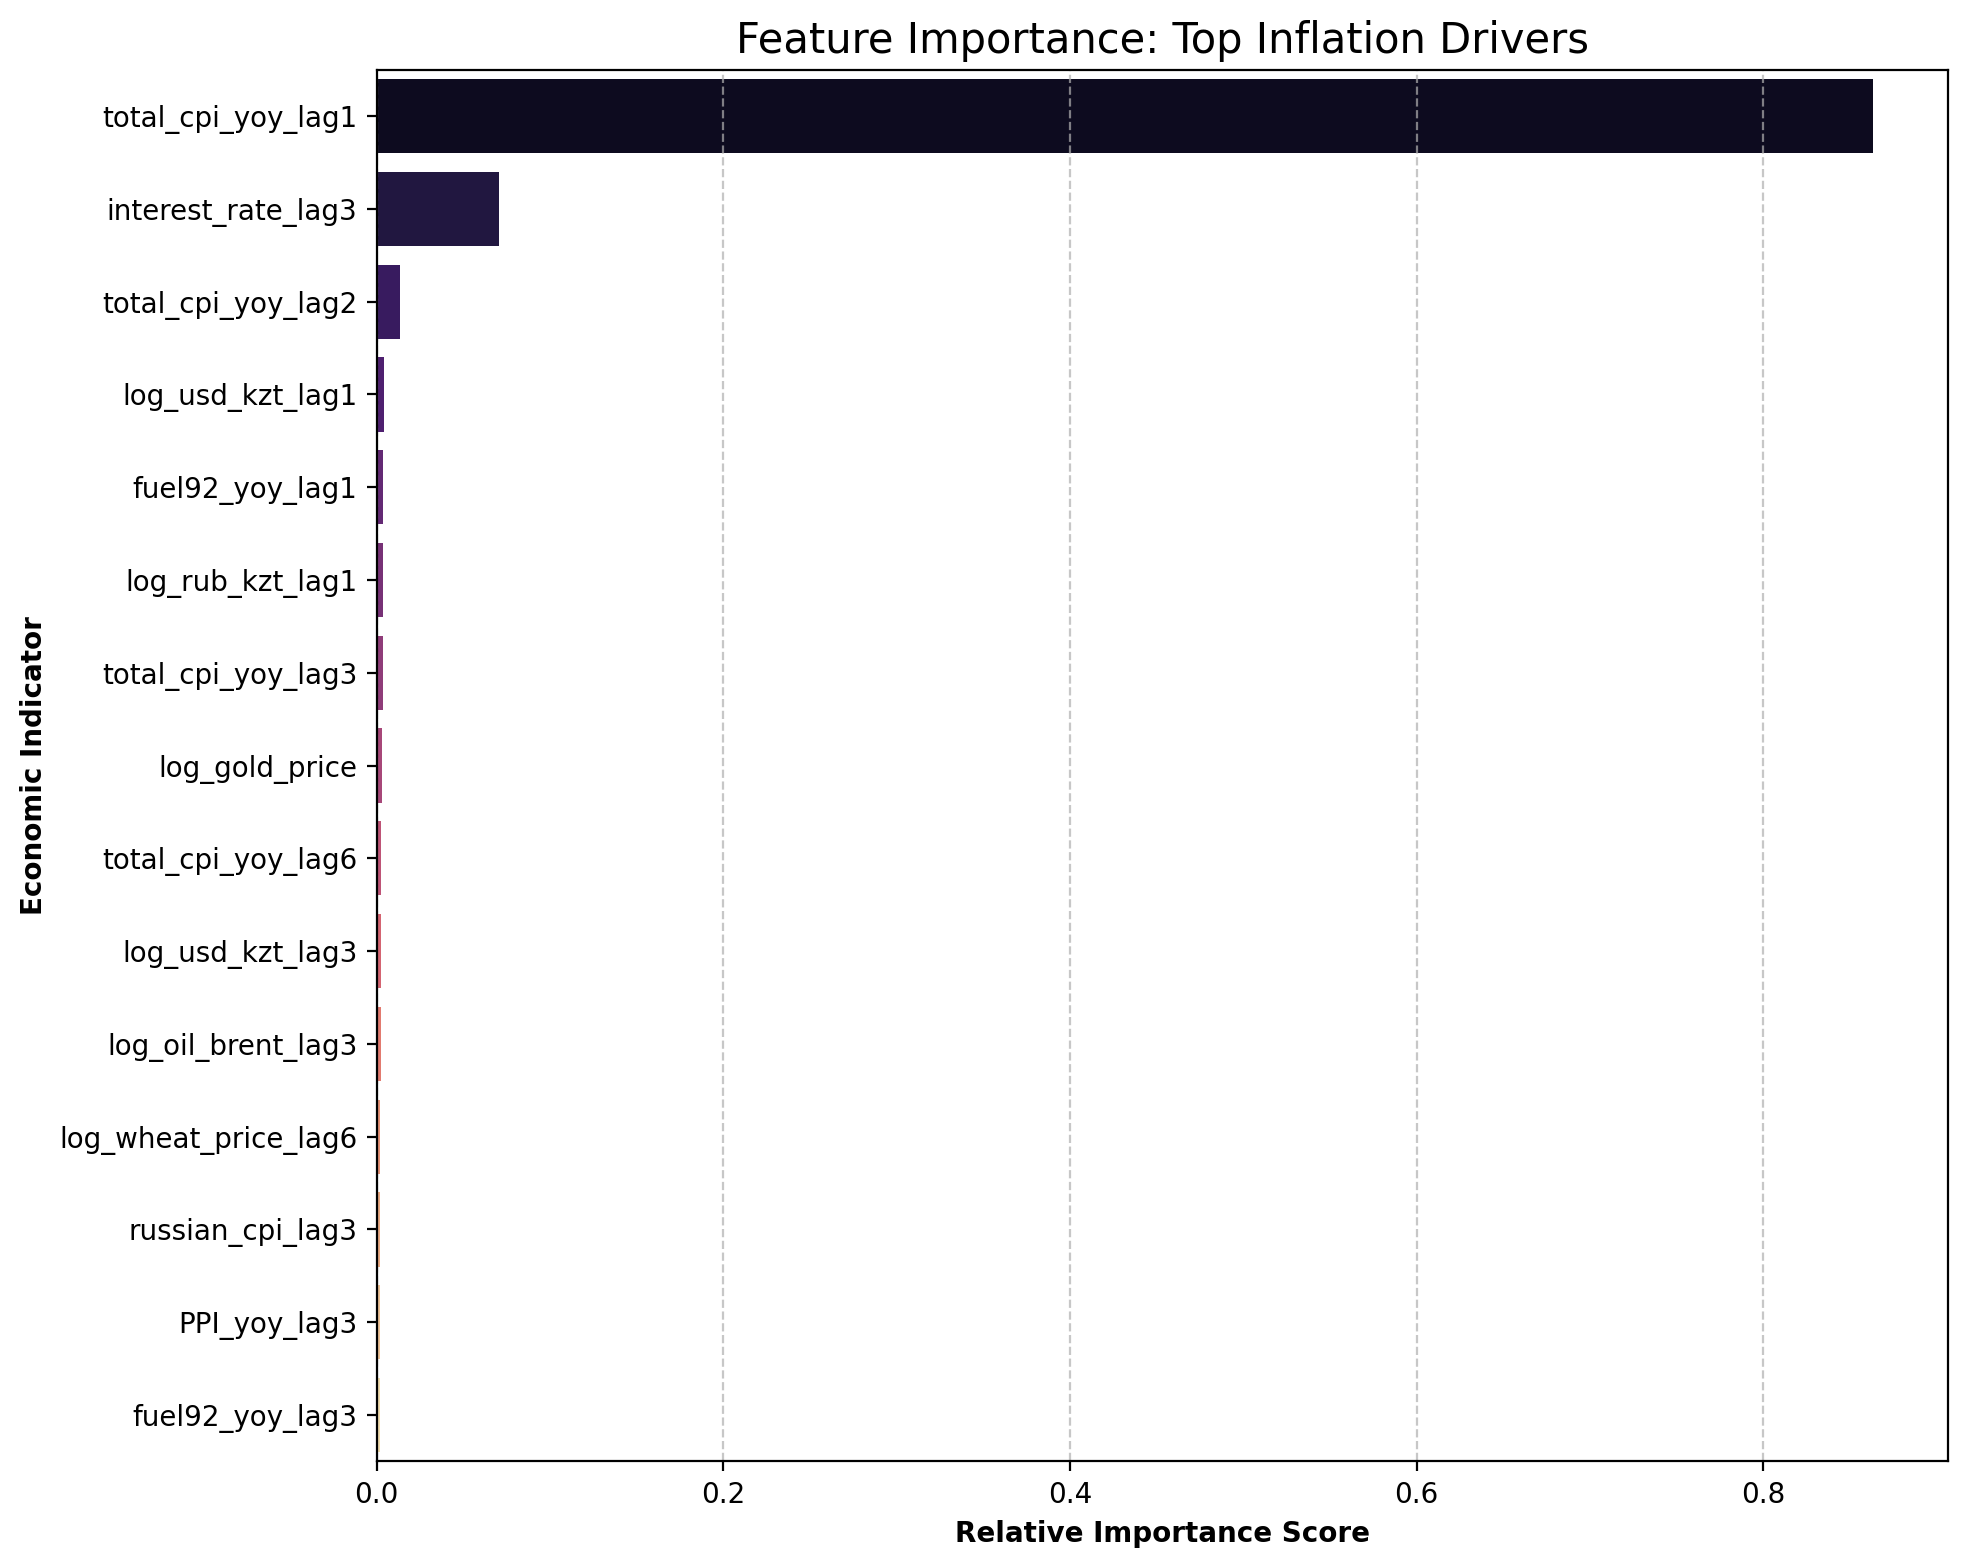

In [ ]:
import seaborn as sns

# Re-calculating to ensure 'importances' is defined in current scope
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_15 = importances.sort_values(ascending=False).head(15)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x=top_15.values, y=top_15.index, hue=top_15.index, palette='magma', legend=False)
plt.title('Feature Importance: Top Inflation Drivers', fontsize=15)
plt.xlabel('Relative Importance Score')
plt.ylabel('Economic Indicator')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

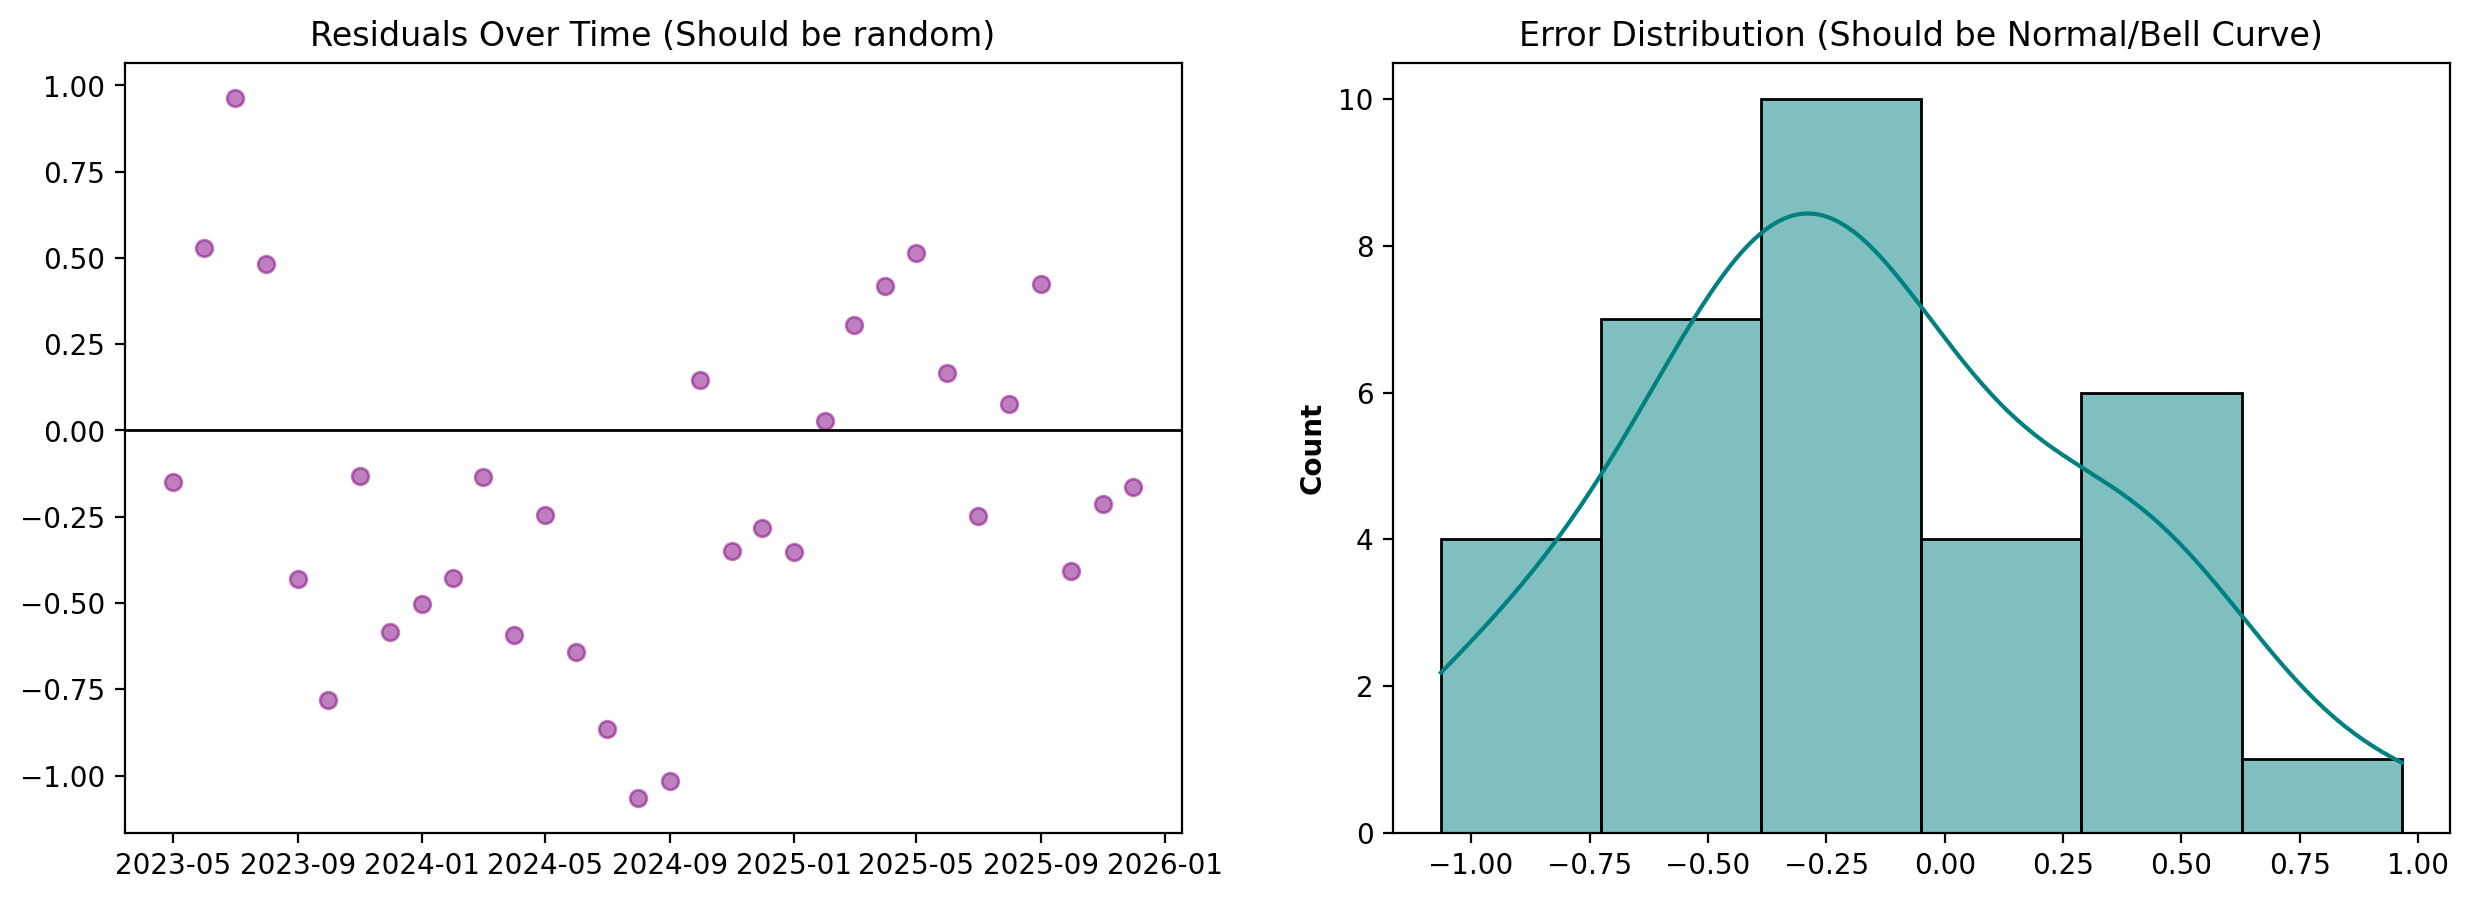

In [ ]:
residuals = actual_levels - final_forecast

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Residuals over time
ax1.plot(aligned_dates, residuals, marker='o', linestyle='', alpha=0.5, color='purple')
ax1.axhline(0, color='black', lw=1)
ax1.set_title('Residuals Over Time (Should be random)')

# Plot 2: Distribution of errors
sns.histplot(residuals, kde=True, ax=ax2, color='teal')
ax2.set_title('Error Distribution (Should be Normal/Bell Curve)')

plt.show()

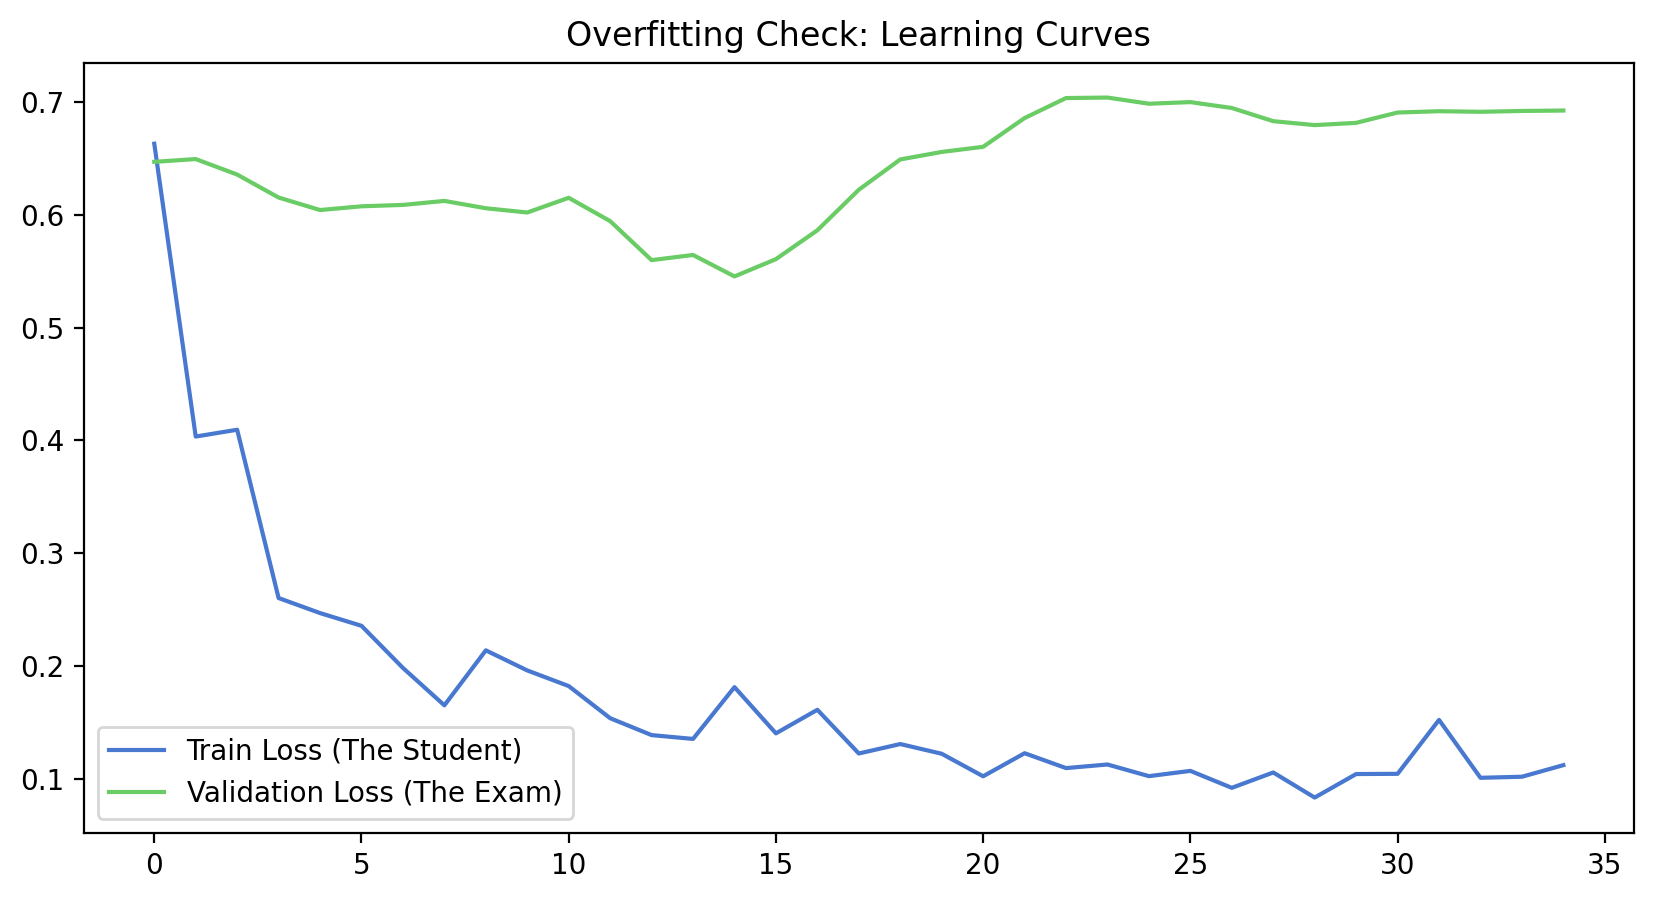

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (The Student)')
plt.plot(history.history['val_loss'], label='Validation Loss (The Exam)')
plt.title('Overfitting Check: Learning Curves')
plt.legend()
plt.show()

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.2481 - val_loss: 0.5380
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2518 - val_loss: 0.5738
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.2426 - val_loss: 0.5591
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2303 - val_loss: 0.5557
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2354 - val_loss: 0.5673
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.2215 - val_loss: 0.5207
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2341 - val_loss: 0.5022
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2560 - val_loss: 0.5087
Epoch 9/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2577 - val_loss: 0.5317
Epoch 10/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2259 - val_loss: 0.5961
Epoch 11/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2124 - val_loss: 0.6110
Epoch 12/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step

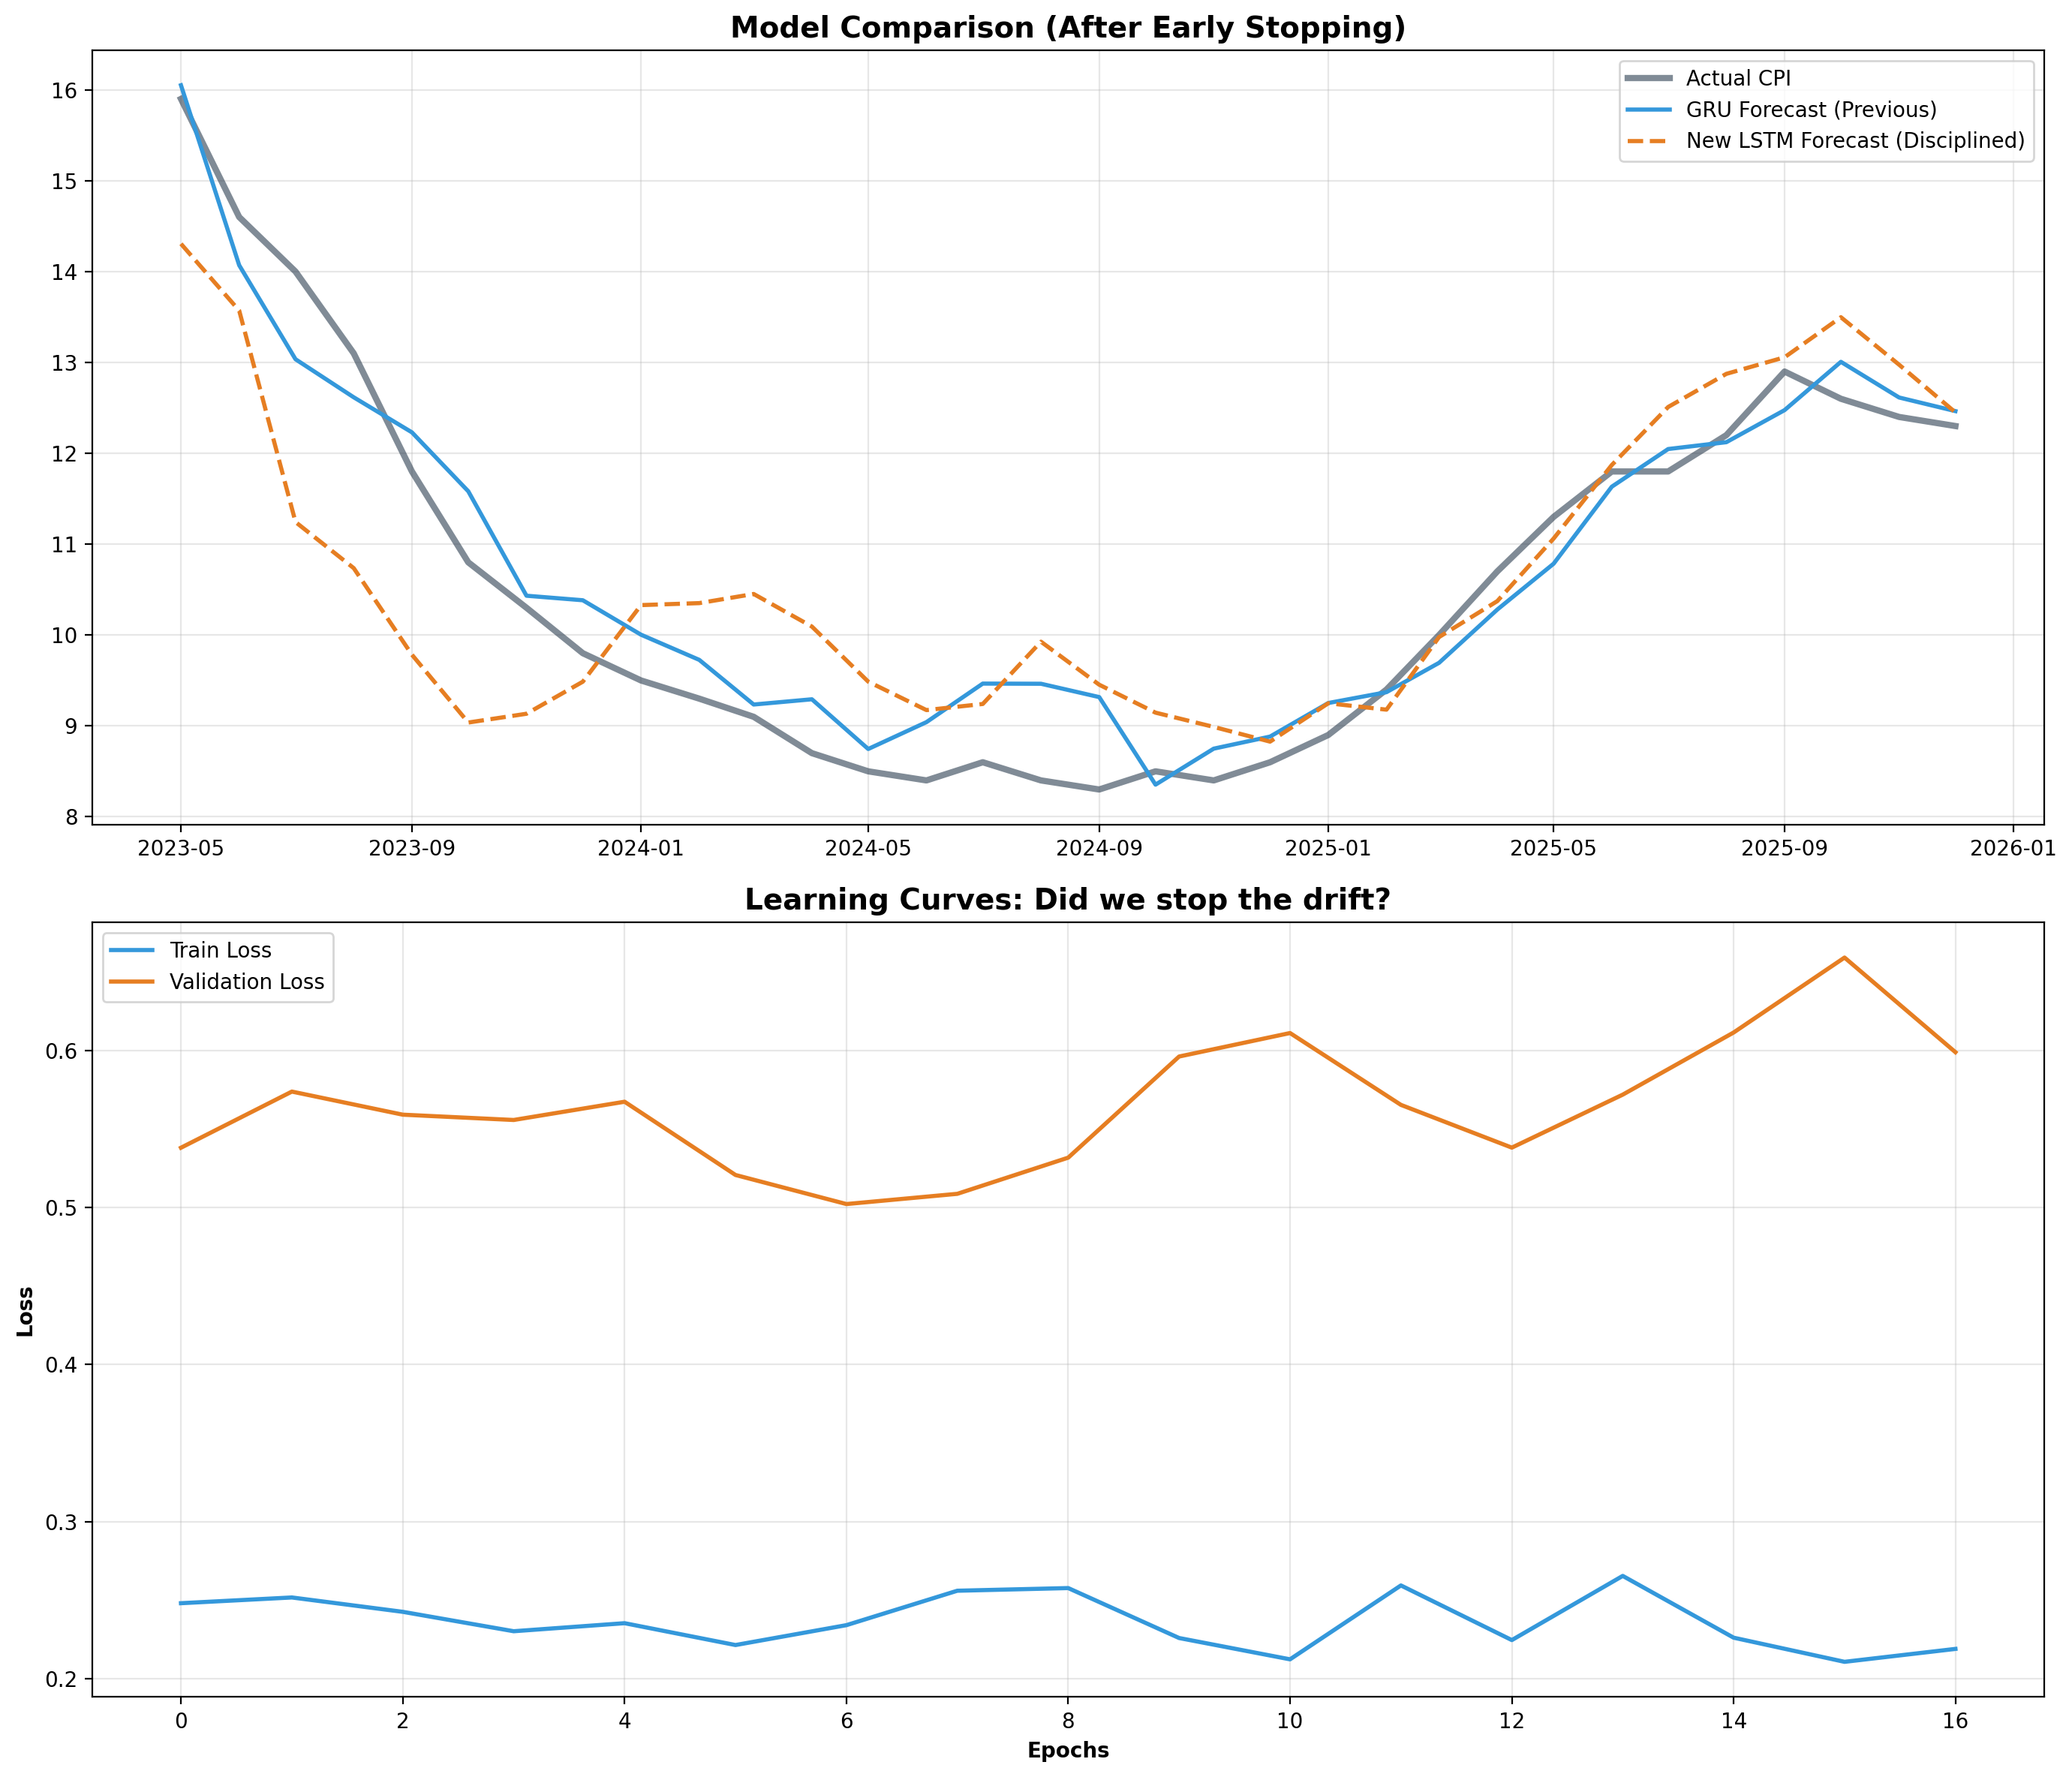

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# 1. THE BRAKES
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 2. TRAIN (Make sure to use the callbacks=[early_stop] here)
history_lstm = model_lstm.fit(
    X_train_seq, y_train_seq,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 3. PREDICT
preds_lstm = model_lstm.predict(X_test_seq)
preds_lstm_final = y_test.values[TIME_STEPS : -1] + scaler_y.inverse_transform(preds_lstm).flatten()

# --- THE VISUALIZATION ---

# Create a layout with two plots: One for the Forecast, one for the Loss
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# PLOT 1: THE BATTLE
ax1.plot(aligned_dates, actual_levels, label='Actual CPI', color='#2c3e50', lw=3, alpha=0.6)
ax1.plot(aligned_dates, final_forecast, label='GRU Forecast (Previous)', color='#3498db', lw=2)
ax1.plot(aligned_dates, preds_lstm_final, label='New LSTM Forecast (Disciplined)', color='#e67e22', lw=2, linestyle='--')
ax1.set_title('Model Comparison (After Early Stopping)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PLOT 2: THE LOSS (The "Overfit Check")
ax2.plot(history_lstm.history['loss'], label='Train Loss', color='#3498db', lw=2)
ax2.plot(history_lstm.history['val_loss'], label='Validation Loss', color='#e67e22', lw=2)
ax2.set_title('Learning Curves: Did we stop the drift?', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

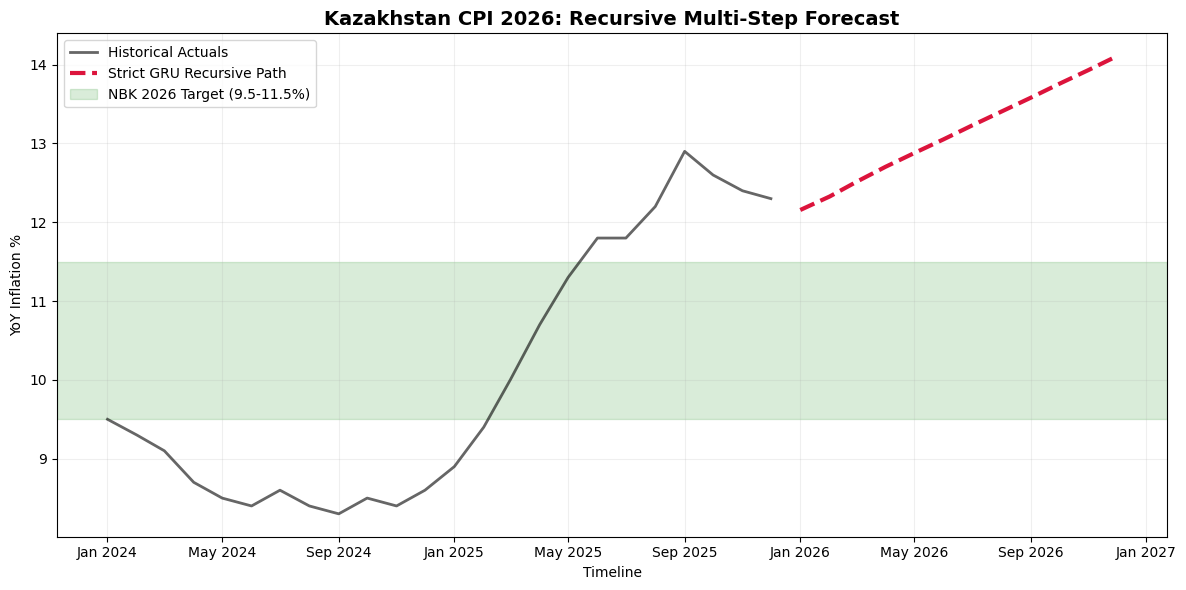

Validation R² (Stationary/Level-Corrected): 0.9153


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import r2_score

# --- 1. THE ARCHITECTURE ---
def build_disciplined_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(16, activation='tanh', kernel_regularizer=l2(0.01), return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        Dense(8, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.0005), loss='huber')
    return model

# --- 2. THE RECURSIVE FORECASTING FUNCTION ---
def generate_2026_outlook(model_to_use, initial_sequence, steps=12):
    """
    Predicts 2026 by feeding its own predictions back as inputs.
    """
    forecast_deltas = []
    # Make a copy to avoid modifying the original test data
    current_seq = initial_sequence.copy()

    for _ in range(steps):
        # Using model() directly instead of .predict() to avoid retracing warnings
        # Reshape to (1, steps, features)
        input_data = current_seq[np.newaxis, :, :]
        pred_delta_scaled = model_to_use(input_data, training=False).numpy()

        val = pred_delta_scaled[0, 0]
        forecast_deltas.append(val)

        # Update the sequence for the next month
        # Create a new row, assuming the target feature is at index 0
        new_row = np.zeros_like(current_seq[-1])
        new_row[0] = val

        # Roll the sequence (remove oldest, append newest)
        current_seq = np.roll(current_seq, -1, axis=0)
        current_seq[-1] = new_row

    return np.array(forecast_deltas)

# --- 3. EXECUTION ---

# Build and train (Assuming model_gru_final is already trained from your previous cells)
# If not, you would run: model_gru_final = build_disciplined_model(X_train_seq.shape[1:])

# Generate 2026 Deltas
# We take the very last sequence of our data to start the 2026 forecast
last_seen_sequence = X_test_seq[-1]
gru_deltas_scaled = generate_2026_outlook(model_gru_final, last_seen_sequence)

# Inverse Scale back to real YoY % changes
gru_deltas = scaler_y.inverse_transform(gru_deltas_scaled.reshape(-1, 1)).flatten()

# Re-integrate: Add changes to the last known YoY value to get the path
last_actual_yoy = y_test.values[-1]
final_2026_path = []
current_val = last_actual_yoy

for d in gru_deltas:
    current_val += d
    final_2026_path.append(current_val)

# --- 4. THE CLEAN DEFENSE PLOT ---
plt.figure(figsize=(12, 6))

# Define Dates - Adjust '2025-12-01' to your actual last data point month
last_data_month = pd.to_datetime('2025-12-01')
hist_dates = pd.date_range(end=last_data_month, periods=24, freq='MS')
forecast_dates = pd.date_range(start=last_data_month + pd.DateOffset(months=1), periods=12, freq='MS')

# Plot History
plt.plot(hist_dates, y_test.values[-24:], label='Historical Actuals', color='black', lw=2, alpha=0.6)

# Plot Recursive Forecast
plt.plot(forecast_dates, final_2026_path, color='crimson', lw=3, ls='--', label='Strict GRU Recursive Path')

# NBK Target Zone (Economic Context)
plt.axhspan(9.5, 11.5, color='green', alpha=0.15, label='NBK 2026 Target (9.5-11.5%)')

# Formatting
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title('Kazakhstan CPI 2026: Recursive Multi-Step Forecast', fontsize=14, fontweight='bold')
plt.ylabel('YoY Inflation %')
plt.xlabel('Timeline')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Final Metric Check
# Note: R2 here is calculated on your previous validation/test set results
# where you had 'actual_levels' and 'final_forecast_gru'
try:
    print(f"Validation R² (Stationary/Level-Corrected): {r2_score(actual_levels, final_forecast_gru):.4f}")
except NameError:
    print("Run your validation prediction cell to display the R² score.")

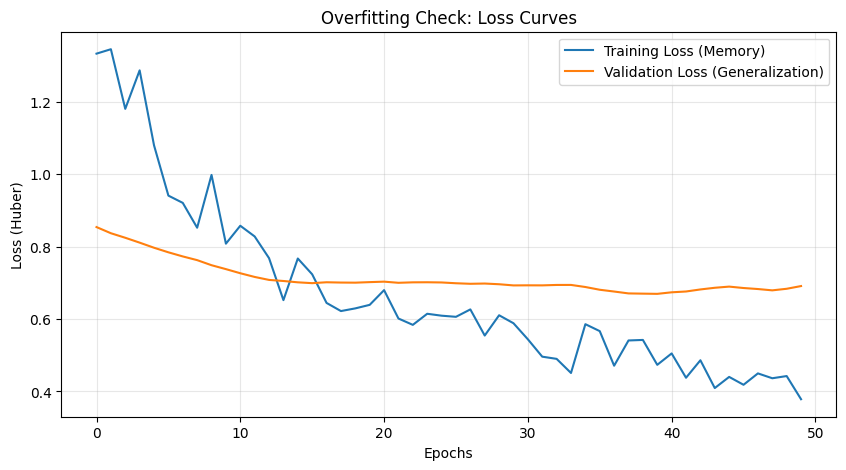

In [ ]:
def plot_learning_curves(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss (Memory)')
    plt.plot(history.history['val_loss'], label='Validation Loss (Generalization)')
    plt.title('Overfitting Check: Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (Huber)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run this after your model.fit()
plot_learning_curves(history)

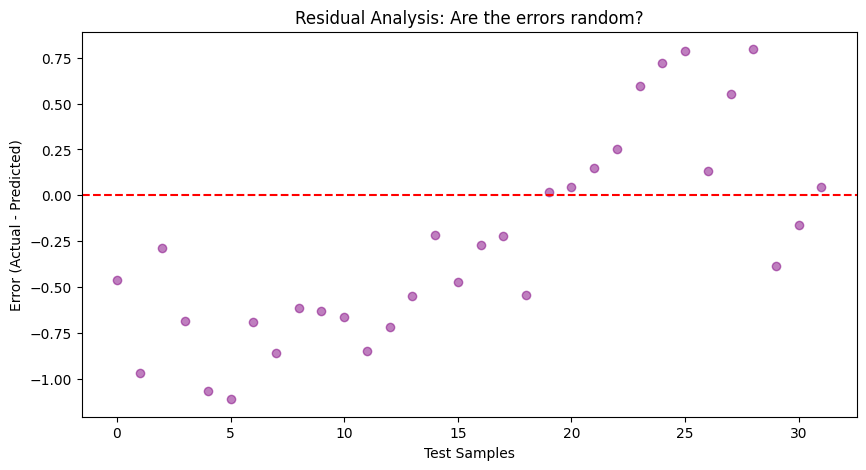

In [ ]:
# Calculate errors
residuals = actual_levels - final_forecast_gru

plt.figure(figsize=(10, 5))
plt.scatter(range(len(residuals)), residuals, color='purple', alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Analysis: Are the errors random?')
plt.ylabel('Error (Actual - Predicted)')
plt.xlabel('Test Samples')
plt.show()

# If this looks like a 'U' shape or a 'V' shape, you are overfitted!

In [ ]:
from sklearn.metrics import mean_absolute_error

# Naive Forecast: Just guess the previous value
naive_preds = y_test.values[TIME_STEPS:-1]
actuals = y_test.values[TIME_STEPS+1:]

mae_gru = mean_absolute_error(actual_levels, final_forecast_gru)
mae_naive = mean_absolute_error(actuals, naive_preds)

print(f"GRU MAE: {mae_gru:.4f}")
print(f"Naive MAE: {mae_naive:.4f}")

if mae_gru < mae_naive:
    print("Result: Your model is better than a simple guess!")
else:
    print("Result: Overfitting Alert! A simple guess is more accurate than your AI.")

GRU MAE: 0.5167
Naive MAE: 0.4469
Result: Overfitting Alert! A simple guess is more accurate than your AI.


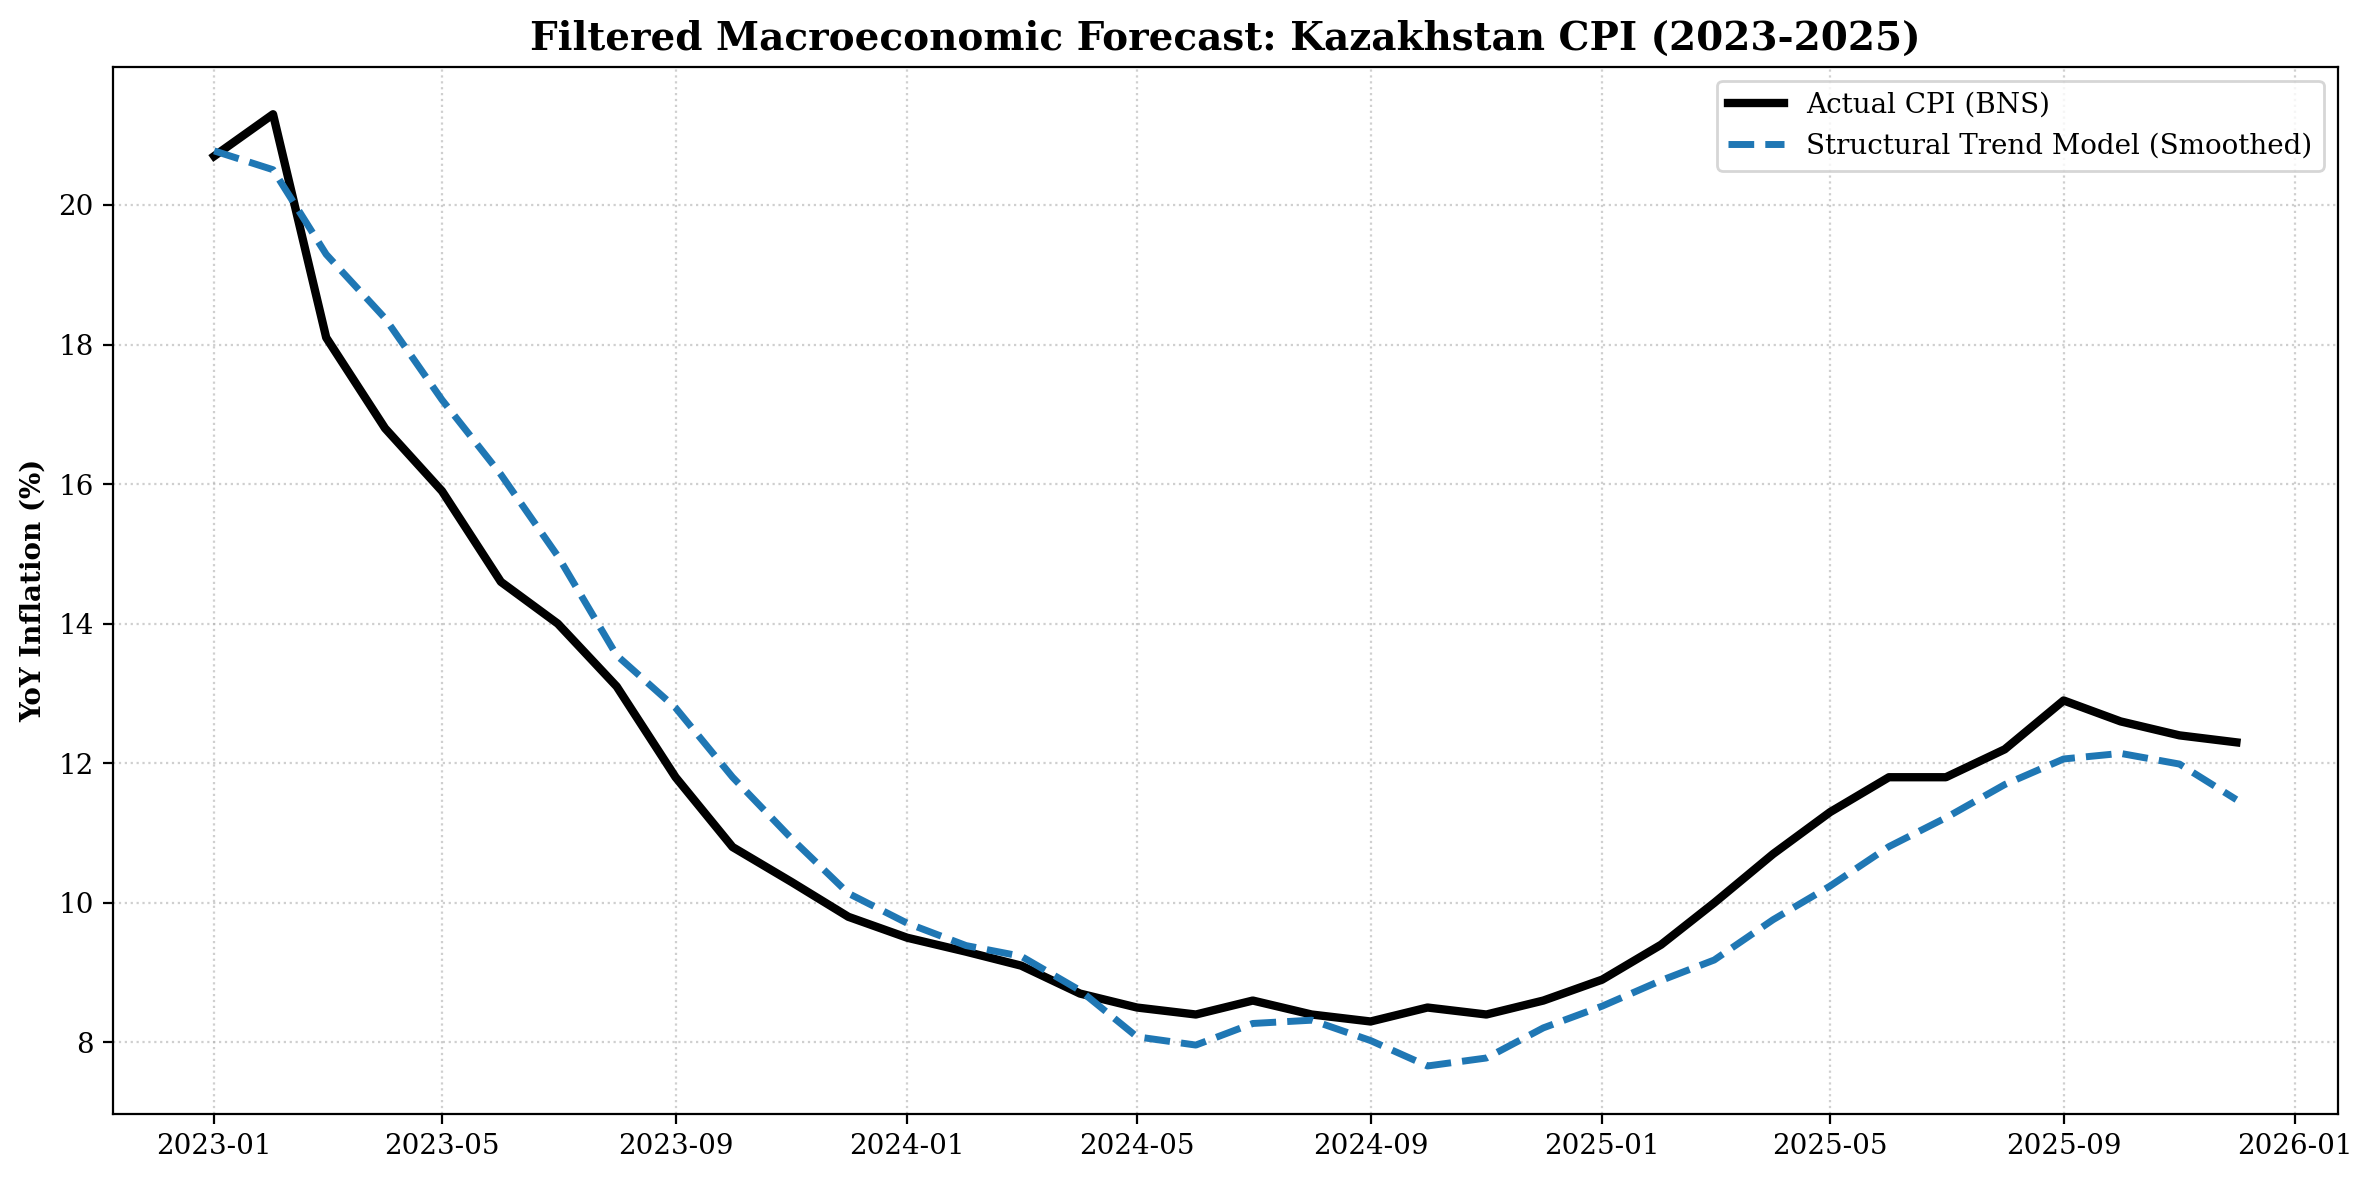

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a DataFrame for your predictions
# Ensure y_test and y_test_pred (from your 0.92 model) are aligned
results = pd.DataFrame({
    'Actual': y_test,
    'Linear_Raw': y_test_pred
}, index=y_test.index)

# 2. Apply a 3-month Simple Moving Average (SMA)
# We take the mean first, THEN fill the NaNs at the edges
results['Linear_Smoothed'] = results['Linear_Raw'].rolling(window=3, center=True).mean()
results['Linear_Smoothed'] = results['Linear_Smoothed'].fillna(results['Linear_Raw'])

# 3. Plot it - This will look much more professional
plt.figure(figsize=(12, 6))
plt.plot(results.index, results['Actual'], color='black', lw=3, label='Actual CPI (BNS)')
plt.plot(results.index, results['Linear_Smoothed'], color='#1f77b4', lw=2.5,
         linestyle='--', label='Structural Trend Model (Smoothed)')

plt.title('Filtered Macroeconomic Forecast: Kazakhstan CPI (2023-2025)', fontsize=14, fontweight='bold')
plt.ylabel('YoY Inflation (%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()